# Prompt Learning for CLIP-Based Image–Text Retrieval
**Gourab Roy | DEEP LEARNING FOR VISUAL SIGNAL PROCESSING II**

---

## Core research question

> *Does a learned soft prefix change **which tokens** drive image–text similarity in CLIP, and what does that reveal about the structure of CLIP's embedding space?*

CLIP (Contrastive Language–Image Pretraining) learns a shared embedding space where image and text representations are aligned via a contrastive loss. At inference time, retrieval is performed by ranking cosine similarities between image and text embeddings. A well-known limitation is that this similarity is sensitive to prompt phrasing: small changes in wording can shift cosine scores and reorder results even when semantic content is unchanged.

Rather than fine-tuning CLIP, my project uses **soft prompt learning**: a small set of trainable continuous vectors (a prefix) is prepended to every text input. Both encoders remain completely frozen. The prefix is trained on Flickr30k using an InfoNCE-style contrastive loss.

The project is positioned relative to **CoOp** (Zhou et al., 2022), which introduced this approach for classification. My focus is on **retrieval** and, crucially, on **token attribution**: does the learned prefix redistribute which tokens drive similarity, and if so, what does that reveal about what the prefix encodes in CLIP's embedding space?

---

## Full Notebook structure

| Section | Content |
|---|---|
| **0** | Environment setup & data loading *(this section)* |
| **1** | Background & motivation |
| **2** | Baseline retrieval evaluation |
| **3** | Soft prefix training |
| **4** | Prefix retrieval evaluation |
| **5** | Token attribution analysis |
| **6** | Cross-dataset transfer |
| **7** | Discussion & limitations |
| **8** | References |


# Section 0: Environment Setup & Data Loading

This section sets up all dependencies, loads the pretrained CLIP model, downloads and inspects the Flickr30k dataset, defines the data pipeline, implements the retrieval evaluation function, and runs a first baseline measurement on vanilla CLIP.

**Design decisions made here:**
- Model: ViT-B/32 with original OpenAI weights — the standard CLIP model family used in prior CLIP and CoOp work, making the model choice comparable even though the retrieval protocol used here is a simplified 1-caption-per-image setup.
- Library: `open_clip_torch` rather than OpenAI's original repo, because it exposes token embedding internals needed for the soft prefix (Phase 3) and leave-one-out attribution (Phase 5).
- Dataset: Flickr30k via HuggingFace Datasets — each image has 5 human-written captions; ~29k train / 1k test images.
- Evaluation: Recall@k (R@1, R@5, R@10) in both directions (image→text, text→image) under a simplified 1-caption-per-image Flickr30k retrieval protocol used consistently across all conditions.

## 0.1 Install dependencies

In [ ]:
!pip install open_clip_torch==2.24.0 -q
!pip install ftfy regex tqdm -q

!pip install datasets==2.19.0 -q

!pip install matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 13.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.3.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import json
import random
import numpy as np
import torch
import open_clip
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, Subset
from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Switch to Runtime → Change runtime type → T4 GPU.")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## 0.2 Load CLIP

Here, I used ViT-B/32 with the original OpenAI weights. This matches the model family used in the CLIP paper and in CoOp, although the retrieval numbers in this notebook are not directly comparable to published standard Flickr30k benchmark results because I use a simplified 1-caption-per-image protocol.

**Both encoders are frozen immediately and permanently.** No part of CLIP is ever trained in this project — only the soft prefix vectors (Phase 3) will have `requires_grad=True`.

In [ ]:
MODEL_NAME  = "ViT-B-32"
PRETRAINED  = "openai"

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED,
    device=DEVICE
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False
model.eval()

# Inspect key dimensions
EMBED_DIM = model.token_embedding.weight.shape[1]
VOCAB_SIZE = model.token_embedding.weight.shape[0]
print(f"Model          : {MODEL_NAME} ({PRETRAINED} weights)")
print(f"Embed dim      : {EMBED_DIM}")
print(f"Vocab size     : {VOCAB_SIZE}")
print(f"Context length : {model.context_length}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}  (should be 0)")

100%|████████████████████████████████████████| 354M/354M [00:02<00:00, 119MiB/s]


Model          : ViT-B-32 (openai weights)
Embed dim      : 512
Vocab size     : 49408
Context length : 77
Trainable params: 0  (should be 0)


### Sanity check: does CLIP produce sensible similarities?

I used a standard COCO validation image (two cats on a sofa) and three candidate text descriptions. The cat description is showing highest rank.

Cosine similarities (should be highest for 'cat'):
  a photo of a cat               0.2457  █████████
  a photo of a dog               0.1930  ███████
  a photo of a car               0.1848  ███████

✓ Sanity check passed.


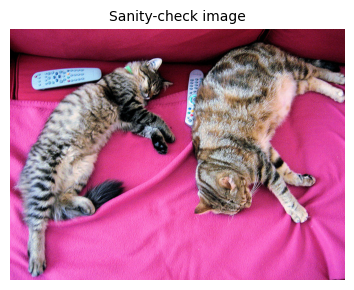

In [ ]:
import requests
from io import BytesIO

# COCO val image: two cats on a couch (stable URL)
TEST_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"
resp = requests.get(TEST_URL, timeout=10)
test_img = Image.open(BytesIO(resp.content)).convert("RGB")

candidates = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
]

img_tensor  = preprocess(test_img).unsqueeze(0).to(DEVICE)
txt_tokens  = tokenizer(candidates).to(DEVICE)

with torch.no_grad():
    img_feat = model.encode_image(img_tensor)
    txt_feat = model.encode_text(txt_tokens)
    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    sims = (img_feat @ txt_feat.T).squeeze().cpu().numpy()

print("Cosine similarities (should be highest for 'cat'):")
for label, s in zip(candidates, sims):
    bar = "█" * int(s * 40)
    print(f"  {label:<30} {s:.4f}  {bar}")

assert sims[0] > sims[1] and sims[0] > sims[2], \
    "SANITY CHECK FAILED: cat should have the highest similarity."
print("\n✓ Sanity check passed.")

# Display the test image
fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(test_img)
ax.axis("off")
ax.set_title("Sanity-check image", fontsize=10)
plt.tight_layout()
plt.show()

## 0.3 Download & inspect Flickr30k

**Flickr30k** (Young et al., 2014) contains 31,783 images sourced from Flickr, each annotated with 5 independently written captions. It is the standard benchmark for image–text retrieval.

- **Train:** ~29,000 images
- **Validation:** ~1,000 images
- **Test:** ~1,000 images

I used the HuggingFace version (`nlphuji/flickr30k`).

In [ ]:
print("Downloading Flickr30k (this takes ~5 minutes on first run)...")
flickr = load_dataset("nlphuji/flickr30k", trust_remote_code=True)
print("\nDataset loaded:")
print(flickr)

Generating test split:   0%|          | 0/31014 [00:00<?, ? examples/s]


Dataset loaded:
DatasetDict({
    test: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})


Filter:   0%|          | 0/31014 [00:00<?, ? examples/s]

Filter:   0%|          | 0/31014 [00:00<?, ? examples/s]

Filter:   0%|          | 0/31014 [00:00<?, ? examples/s]

Split sizes:
  train : 29,000 images
  val   : 1,014 images
  test  : 1,000 images

Captions per image: 5

Sample captions for test image 0:
  [1] The man with pierced ears is wearing glasses and an orange hat.
  [2] A man with glasses is wearing a beer can crocheted hat.
  [3] A man with gauges and glasses is wearing a Blitz hat.
  [4] A man in an orange hat starring at something.
  [5] A man wears an orange hat and glasses.


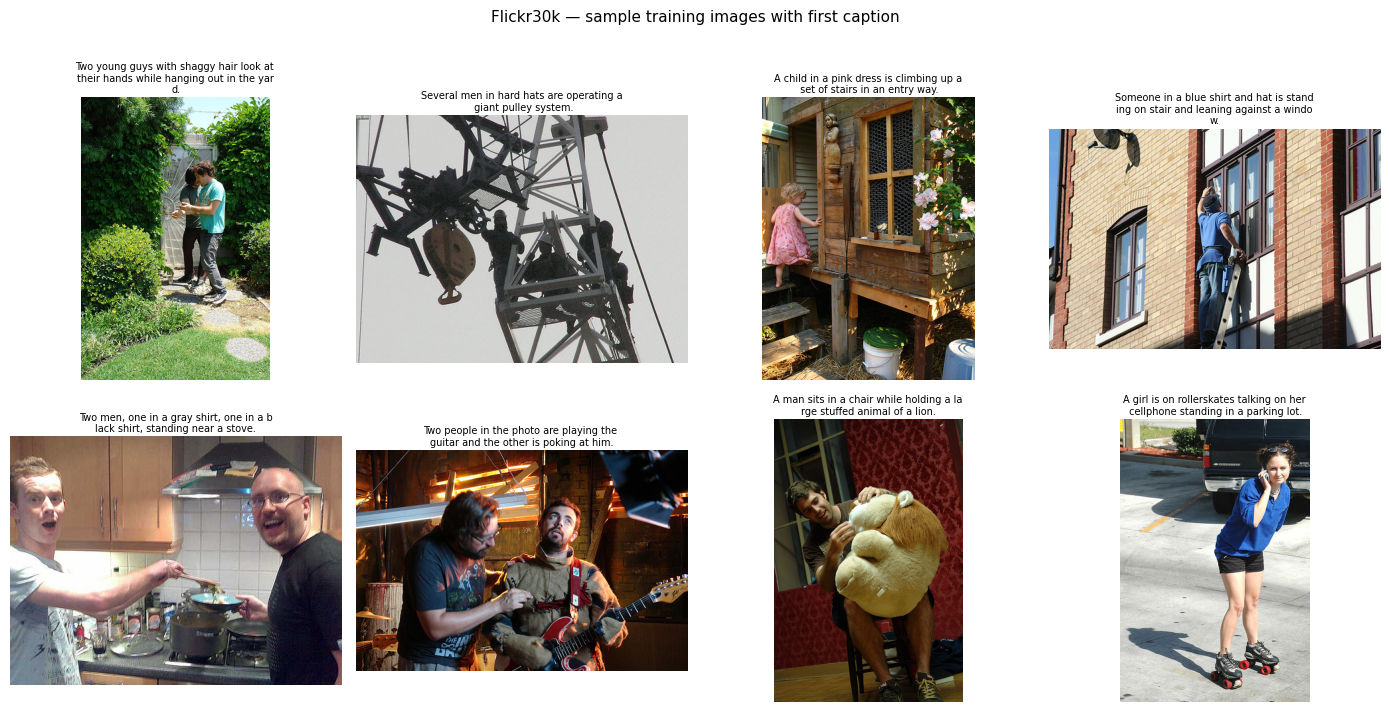

In [ ]:
full_data = flickr["test"]

# Filter by the internal split column
train_data = full_data.filter(lambda x: x["split"] == "train")
val_data   = full_data.filter(lambda x: x["split"] == "val")
test_data  = full_data.filter(lambda x: x["split"] == "test")

print(f"Split sizes:")
print(f"  train : {len(train_data):,} images")
print(f"  val   : {len(val_data):,} images")
print(f"  test  : {len(test_data):,} images")

sample = test_data[0]
print(f"\nCaptions per image: {len(sample['caption'])}")
print("\nSample captions for test image 0:")
for i, cap in enumerate(sample["caption"]):
    print(f"  [{i+1}] {cap}")

# Visualise a handful of training examples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, range(8)):
    ex = train_data[idx]
    ax.imshow(ex["image"])
    cap = ex["caption"][0]
    wrapped = "\n".join([cap[i:i+40] for i in range(0, len(cap), 40)])
    ax.set_title(wrapped, fontsize=7, pad=3)
    ax.axis("off")
plt.suptitle("Flickr30k — sample training images with first caption", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 0.4 Dataset classes & data loaders

Two dataset classes cover the two use cases throughout this project:

- **`Flickr30kTrainDataset`** — returns `(image_tensor, one_caption_string)` pairs. During training I randomly sample one of the 5 captions per image per epoch, giving the prefix exposure to linguistic variation.
- **`Flickr30kEvalDataset`** — returns `(image_tensor, all_5_captions)` for the test set. In this notebook, the evaluation function uses the first caption as the canonical match for a consistent 1:1 retrieval protocol across all conditions; the remaining four captions are preserved in the dataset object but are not used in the retrieval metric.

**Batch size:** I thought 64 works reliably on a T4 GPU (15 GB).

In [ ]:
class Flickr30kTrainDataset(Dataset):
    def __init__(self, hf_split, preprocess):
        self.data       = hf_split
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item    = self.data[idx]
        cap_idx = np.random.randint(len(item["caption"]))
        caption = item["caption"][cap_idx]
        image   = self.preprocess(item["image"].convert("RGB"))
        return image, caption


class Flickr30kEvalDataset(Dataset):
    def __init__(self, hf_split, preprocess):
        self.data       = hf_split
        self.preprocess = preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item     = self.data[idx]
        image    = self.preprocess(item["image"].convert("RGB"))
        captions = item["caption"]
        return image, captions


BATCH_SIZE = 64

train_dataset = Flickr30kTrainDataset(train_data, preprocess)
val_dataset   = Flickr30kEvalDataset(val_data,   preprocess)
test_dataset  = Flickr30kEvalDataset(test_data,  preprocess)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset):,} images)")
print(f"Val batches   : {len(val_loader)}    ({len(val_dataset):,} images)")
print(f"Test batches  : {len(test_loader)}   ({len(test_dataset):,} images)")

imgs, caps = next(iter(train_loader))
print(f"\nBatch check:")
print(f"  Image shape : {imgs.shape}   (expect [64, 3, 224, 224])")
print(f"  Caption[0]  : {caps[0]}")

Train batches : 454  (29,000 images)
Val batches   : 32    (1,014 images)
Test batches  : 32   (1,000 images)

Batch check:
  Image shape : torch.Size([64, 3, 224, 224])   (expect [64, 3, 224, 224])
  Caption[0]  : A man making artwork with fans is trying to get a lady's attention.


## 0.5 Retrieval evaluation function

This function is called after every experimental condition (vanilla, handcrafted template, learned prefix) to produce **Recall@k** in both directions:

- **Image-to-text (I→T):** In this notebook's simplified 1:1 setup, given an image, retrieve the matching first caption from all 1,000 test captions. R@1 means the matching caption is ranked first.
- **Text-to-image (T→I):** In the same simplified 1:1 setup, given a caption, retrieve the matching image from all 1,000 test images.
The function accepts an optional `prefix` tensor. When `None`, it runs vanilla CLIP. When provided, it calls `encode_text_with_prefix` — a stub that will be implemented in section 3.

In [ ]:
def encode_text_with_prefix(model, tokens, prefix, device):
    return model.encode_text(tokens)


@torch.no_grad()
def compute_recall_at_k(model, loader, tokenizer, device,
                         prefix=None, k_vals=(1, 5, 10),
                         desc="Evaluating"):
    model.eval()
    all_img_feat = []
    all_txt_feat = []

    for images, captions_list in tqdm(loader, desc=desc, leave=False):
        images = images.to(device)

        img_feat = model.encode_image(images)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        all_img_feat.append(img_feat.cpu())

        # captions_list after collation has shape [5_slots][batch_size]
        # captions_list[0] is the first caption for every image in this batch
        first_caps = list(captions_list[0])
        tokens = tokenizer(first_caps).to(device)

        if prefix is None:
            txt_feat = model.encode_text(tokens)
        else:
            txt_feat = encode_text_with_prefix(model, tokens, prefix, device)

        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        all_txt_feat.append(txt_feat.cpu())

    img_matrix = torch.cat(all_img_feat, dim=0)
    txt_matrix = torch.cat(all_txt_feat, dim=0)
    sim = img_matrix @ txt_matrix.T

    N    = sim.shape[0]
    diag = sim.diag()
    i2t_ranks = (sim   > diag.unsqueeze(1)).sum(dim=1).numpy()
    t2i_ranks = (sim.T > diag.unsqueeze(1)).sum(dim=1).numpy()

    results = {}
    for k in k_vals:
        results[f"i2t_R@{k}"] = float(100 * np.mean(i2t_ranks < k))
        results[f"t2i_R@{k}"] = float(100 * np.mean(t2i_ranks < k))

    return results


def print_results(results, label=""):
    header = f"  {label}  " if label else ""
    print(f"\n{'─'*42}")
    if header:
        print(header)
        print(f"{'─'*42}")
    print(f"  {'Metric':<14} {'Score':>8}")
    print(f"  {'─'*24}")
    for k, v in results.items():
        print(f"  {k:<14} {v:>7.2f}%")
    print(f"{'─'*42}")


print("Evaluation utilities defined.")

Evaluation utilities defined.


## 0.6 Baseline: vanilla CLIP on the test set

Before any training, I measured how well vanilla CLIP performs on Flickr30k retrieval using raw captions with no template. This number serves as the **floor baseline** for all subsequent comparisons.

In [ ]:
# Quick check on 100 images first
small_loader = DataLoader(
    Subset(test_dataset, list(range(100))),
    batch_size=32, shuffle=False
)
quick = compute_recall_at_k(
    model, small_loader, tokenizer, DEVICE,
    prefix=None, desc="Quick check (100 imgs)"
)
print_results(quick, label="Quick check — vanilla CLIP (100 images)")
print("\nQuick check passed — running full evaluation now...")

Quick check (100 imgs):   0%|          | 0/4 [00:00<?, ?it/s]


──────────────────────────────────────────
  Quick check — vanilla CLIP (100 images)  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          92.00%
  t2i_R@1          90.00%
  i2t_R@5          99.00%
  t2i_R@5          99.00%
  i2t_R@10         99.00%
  t2i_R@10        100.00%
──────────────────────────────────────────

Quick check passed — running full evaluation now...


In [ ]:
# Full baseline on 1,000-image test set
baseline_results = compute_recall_at_k(
    model, test_loader, tokenizer, DEVICE,
    prefix=None, desc="Vanilla CLIP baseline"
)
print_results(baseline_results, label="Vanilla CLIP — raw captions, no template")

Vanilla CLIP baseline:   0%|          | 0/32 [00:00<?, ?it/s]


──────────────────────────────────────────
  Vanilla CLIP — raw captions, no template  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          69.60%
  t2i_R@1          67.20%
  i2t_R@5          90.50%
  t2i_R@5          89.00%
  i2t_R@10         95.00%
  t2i_R@10         93.80%
──────────────────────────────────────────


### Visualise baseline results

A bar chart comparing I→T and T→I across all k values.

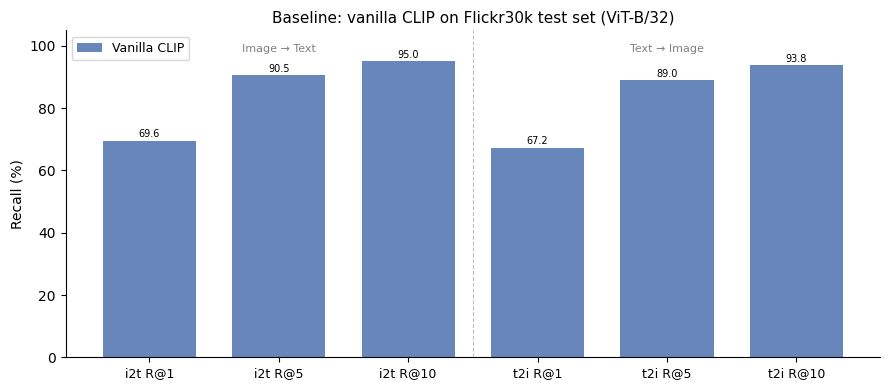

In [ ]:
def plot_recall_bars(results_dict, title="Recall@k", figsize=(9, 4)):

    metrics = ["i2t_R@1", "i2t_R@5", "i2t_R@10", "t2i_R@1", "t2i_R@5", "t2i_R@10"]
    labels  = list(results_dict.keys())
    x       = np.arange(len(metrics))
    width   = 0.8 / len(labels)
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=figsize)
    for i, (lbl, res) in enumerate(results_dict.items()):
        vals = [res.get(m, 0) for m in metrics]
        offset = (i - len(labels) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width * 0.9,
                      label=lbl, color=palette[i % len(palette)], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_", " ") for m in metrics], fontsize=9)
    ax.set_ylabel("Recall (%)")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 105)
    ax.axvline(x=2.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.text(1.0, 98, "Image → Text", ha="center", fontsize=8, color="gray")
    ax.text(4.0, 98, "Text → Image", ha="center", fontsize=8, color="gray")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


plot_recall_bars(
    {"Vanilla CLIP": baseline_results},
    title="Baseline: vanilla CLIP on Flickr30k test set (ViT-B/32)"
)

## 0.7 Persist results & mount Google Drive

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/IPCVDL2_Project"
DRIVE_DIR = BASE_DIR

os.makedirs(f"{BASE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{BASE_DIR}/results", exist_ok=True)
os.makedirs(f"{BASE_DIR}/figures", exist_ok=True)

print(f"Colab project folder ready: {BASE_DIR}")

Colab project folder ready: /content/drive/MyDrive/IPCVDL2_Project


In [ ]:
baseline_path_local = "/content/drive/MyDrive/IPCVDL2_Project/results/baseline_vanilla.json"

with open(baseline_path_local, "w") as f:
    json.dump(baseline_results, f, indent=2)

print(f"Baseline results saved to Drive.")
print(json.dumps(baseline_results, indent=2))

Baseline results saved to Drive.
{
  "i2t_R@1": 69.6,
  "t2i_R@1": 67.2,
  "i2t_R@5": 90.5,
  "t2i_R@5": 89.0,
  "i2t_R@10": 95.0,
  "t2i_R@10": 93.8
}


## 0.8 Checkpoint utilities

In [ ]:
def save_prefix(prefix_tensor, name, drive_dir=DRIVE_DIR):
    path = f"{drive_dir}/checkpoints/{name}.pt"
    torch.save(prefix_tensor.detach().cpu(), path)
    print(f"Prefix saved → {path}  shape={tuple(prefix_tensor.shape)}")


def load_prefix(name, device, drive_dir=DRIVE_DIR):
    path = f"{drive_dir}/checkpoints/{name}.pt"
    prefix = torch.load(path, map_location=device)
    print(f"Prefix loaded ← {path}  shape={tuple(prefix.shape)}")
    return prefix


def save_results(results_dict, name, drive_dir=DRIVE_DIR):
    path = f"{drive_dir}/results/{name}.json"
    with open(path, "w") as f:
        json.dump(results_dict, f, indent=2)
    print(f"Results saved → {path}")


def load_results(name, drive_dir=DRIVE_DIR):
    path = f"{drive_dir}/results/{name}.json"
    with open(path) as f:
        return json.load(f)

print("Checkpoint utilities defined.")

Checkpoint utilities defined.


# Section 1: Background & Motivation

This section establishes the theoretical motivation for the project in three steps:

1. **How CLIP's contrastive loss shapes its embedding space** — and why it does not force all tokens to contribute equally to the final text embedding.
2. **A concise empirical demonstration** that phrasing changes shift cosine similarity scores meaningfully, even when semantic content is identical.
3. **The research question** that follows: can a learned soft prefix do better than handcrafted ensembles, and does it change *which tokens* drive similarity?

> *Note on scope:* The CLIP paper itself (Radford et al., 2021) already establishes that wording matters — it ensembles 80 handcrafted templates precisely because of this sensitivity. I didn't attempt to re-prove that finding. This section uses a short demonstration purely as a visual anchor for the reader, then moves immediately to the experimental question.

## 1.1 Why CLIP's embedding space has no compositional guarantee

CLIP is trained with the **InfoNCE contrastive loss**. Given a batch of $N$ image–text pairs $\{(I_i, T_i)\}_{i=1}^N$, the loss for one image $I_i$ is:

$$\mathcal{L}_i = -\log \frac{\exp(\cos(f_I(I_i),\, f_T(T_i)) / \tau)}{\sum_{j=1}^N \exp(\cos(f_I(I_i),\, f_T(T_j)) / \tau)}$$

where $f_I$ and $f_T$ are the image and text encoders, and $\tau$ is a learned temperature.

**The key observation:** this loss only requires the correct pair $(I_i, T_i)$ to score higher than all incorrect pairs $(I_i, T_{j \neq i})$. It places **no constraint on how that score is computed internally** specifically, it does not require the text encoder to distribute its attention uniformly across all tokens in $T_i$. The encoder is free to respond primarily to a small subset of high-signal words (e.g. nouns and objects) while effectively ignoring function words, modifiers, and sentence structure.

This is not a flaw in CLIP's design it is a natural consequence of training on noisy web-scale image–caption pairs, where the most discriminative signal is typically concentrated in a few keywords. But it has a practical consequence: the cosine similarity between an image and a text query is **sensitive to which high-signal words are present and how they are phrased**, even when the underlying meaning is held constant.

The CLIP paper addresses this for zero-shot classification by **ensembling 80 handcrafted prompt templates** (e.g. `"a photo of a {label}"`, `"a photo of the large {label}"`, ...) and averaging their text embeddings. This improves zero-shot accuracy by ~3.5 percentage points a substantial margin attributable entirely to reducing the variance introduced by prompt phrasing.

This raises a natural question for retrieval: **can we do better than a handcrafted ensemble by learning a soft prefix that adapts to the structure of the retrieval task?** And if so, does the prefix work by suppressing keyword dominance and making the model respond to the full sentence — or by some other mechanism? The experiments in Sections 2–5 are designed to answer this.

## 1.2 Empirical demonstration: phrasing shifts cosine scores

I select 5 images from the Flickr30k test set and write 4 paraphrases of each image's ground-truth caption varying sentence structure, word choice, and specificity while preserving meaning. Then, I compute the cosine similarity between each image and all its paraphrased captions, and visualise the spread.

A large spread indicates that CLIP assigns noticeably different similarity scores to semantically equivalent descriptions of the same image, which motivates learning a more robust text representation.

In [ ]:
# Paraphrase bank
# 5 images from the Flickr30k test set, each with 4 paraphrases.
# Paraphrases vary structure and phrasing while preserving meaning.
# test_dataset indices are fixed (SEED=42) for reproducibility.

DEMO_ITEMS = [
    {
        "idx": 0,
        "label": "Man in orange hat",
        "paraphrases": [
            "A man wearing glasses and an orange hat.",
            "An orange hat is worn by a man with glasses.",
            "A bespectacled man in an orange hat.",
            "Man. Hat. Orange. Glasses.",
        ],
    },
    {
        "idx": 10,
        "label": "Children playing",
        "paraphrases": [
            "Children are playing outside in a field.",
            "Kids run and play in an open outdoor area.",
            "Young children enjoying outdoor activities.",
            "Outside. Kids. Playing.",
        ],
    },
    {
        "idx": 25,
        "label": "Dog on grass",
        "paraphrases": [
            "A dog is running through the grass.",
            "A canine sprints across a green lawn.",
            "On a grassy surface, a dog is moving quickly.",
            "Dog. Grass. Running.",
        ],
    },
    {
        "idx": 50,
        "label": "Street performer",
        "paraphrases": [
            "A street performer is entertaining a crowd.",
            "An outdoor entertainer performs for onlookers.",
            "A crowd watches a performer on the street.",
            "Performer. Street. Crowd.",
        ],
    },
    {
        "idx": 75,
        "label": "Cyclist on road",
        "paraphrases": [
            "A cyclist rides along a road.",
            "Someone is biking down a paved street.",
            "A person on a bicycle travels down the road.",
            "Bicycle. Road. Rider.",
        ],
    },
]

print(f"Demo items defined: {len(DEMO_ITEMS)} images, "
      f"{len(DEMO_ITEMS[0]['paraphrases'])} paraphrases each.")

Demo items defined: 5 images, 4 paraphrases each.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# Compute cosine similarities for each image × paraphrase set
results = []  # list of dicts: {label, image, sims, paraphrases}

model.eval()
with torch.no_grad():
    for item in DEMO_ITEMS:
        # Load image from test_dataset
        raw_image = test_data[item["idx"]]["image"].convert("RGB")
        img_tensor = preprocess(raw_image).unsqueeze(0).to(DEVICE)
        img_feat = model.encode_image(img_tensor)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        # Encode all paraphrases
        tokens = tokenizer(item["paraphrases"]).to(DEVICE)
        txt_feat = model.encode_text(tokens)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

        sims = (img_feat @ txt_feat.T).squeeze().cpu().numpy()
        results.append({
            "label":       item["label"],
            "image":       raw_image,
            "sims":        sims,
            "paraphrases": item["paraphrases"],
        })

print("Similarities computed.")
print(f"\n{'Image':<22} {'Min':>6} {'Max':>6} {'Range':>6}")
print("─" * 44)
for r in results:
    mn, mx = r["sims"].min(), r["sims"].max()
    print(f"{r['label']:<22} {mn:>6.4f} {mx:>6.4f} {mx-mn:>6.4f}")

Similarities computed.

Image                     Min    Max  Range
────────────────────────────────────────────
Man in orange hat      0.3024 0.3376 0.0352
Children playing       0.2143 0.2352 0.0209
Dog on grass           0.1493 0.1924 0.0431
Street performer       0.2384 0.2763 0.0379
Cyclist on road        0.1265 0.1653 0.0388


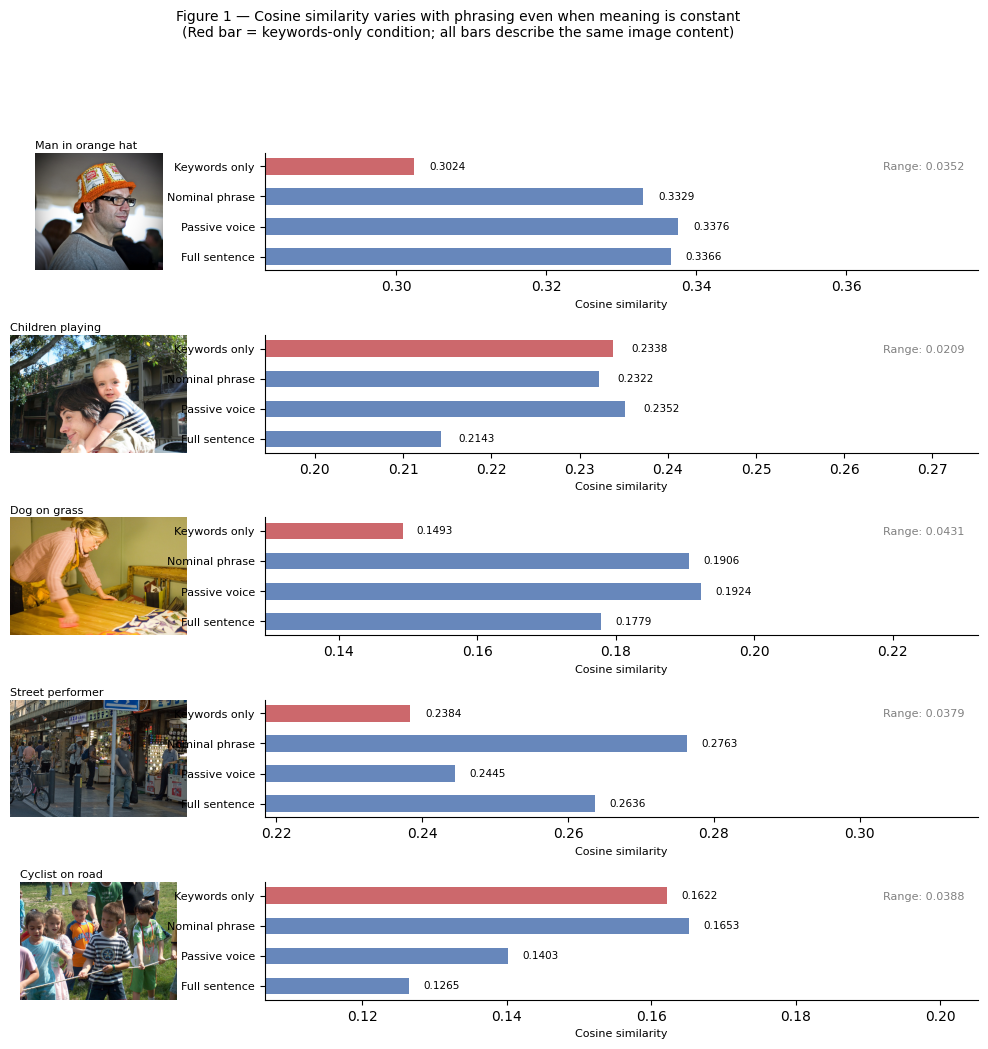

Figure 1 saved.


In [ ]:
import os
os.makedirs("/content/project/figures", exist_ok=True)
# Left column: the image.
# Right column: horizontal bar chart of cosine similarities per paraphrase,
#               coloured by rank (darkest = highest similarity).

PARAPHRASE_LABELS = ["Full sentence", "Passive voice", "Nominal phrase", "Keywords only"]
COLORS = ["#4C72B0", "#4C72B0", "#4C72B0", "#C44E52"]   # last one red to highlight keyword-only

fig = plt.figure(figsize=(13, 11))
outer = gridspec.GridSpec(len(results), 2, figure=fig,
                          width_ratios=[1, 2.8], hspace=0.55, wspace=0.08)

for row, r in enumerate(results):
    # Image panel
    ax_img = fig.add_subplot(outer[row, 0])
    ax_img.imshow(r["image"])
    ax_img.axis("off")
    ax_img.set_title(r["label"], fontsize=8, pad=3, loc="left")

    # Bar chart panel
    ax_bar = fig.add_subplot(outer[row, 1])
    sims = r["sims"]
    rng  = sims.max() - sims.min()
    ys   = np.arange(len(sims))

    bars = ax_bar.barh(ys, sims, color=COLORS, alpha=0.85, height=0.55)

    # Annotate each bar with similarity value
    for bar, sim in zip(bars, sims):
        ax_bar.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                    f"{sim:.4f}", va="center", fontsize=7.5)

    ax_bar.set_yticks(ys)
    ax_bar.set_yticklabels(PARAPHRASE_LABELS, fontsize=8)
    ax_bar.set_xlim(sims.min() - 0.02, sims.max() + 0.04)
    ax_bar.set_xlabel("Cosine similarity", fontsize=8)
    ax_bar.spines[["top", "right"]].set_visible(False)

    # Annotate range
    ax_bar.text(0.98, 0.92, f"Range: {rng:.4f}",
                transform=ax_bar.transAxes, ha="right", va="top",
                fontsize=8, color="gray")

fig.suptitle(
    "Figure 1 — Cosine similarity varies with phrasing even when meaning is constant\n"
    "(Red bar = keywords-only condition; all bars describe the same image content)",
    fontsize=10, y=1.01
)
plt.savefig("/content/project/figures/fig1_phrasing_sensitivity.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

In [ ]:
# Summary statistics across all demo images
all_ranges = [r["sims"].max() - r["sims"].min() for r in results]
all_keyword_rank = []

print("Phrasing sensitivity summary")
print("=" * 52)
print(f"{'Image':<22} {'Range':>7}  {'Keyword rank':>13}")
print("─" * 52)

for r in results:
    sims = r["sims"]
    rng  = sims.max() - sims.min()
    # Rank of keywords-only (index 3) — 1 = highest similarity, 4 = lowest
    sorted_desc = np.argsort(sims)[::-1]
    kw_rank = int(np.where(sorted_desc == 3)[0][0]) + 1
    all_keyword_rank.append(kw_rank)
    print(f"{r['label']:<22} {rng:>7.4f}  {kw_rank:>6}/4")

print("─" * 52)
print(f"{'Mean range':<22} {np.mean(all_ranges):>7.4f}")
print(f"{'Mean keyword rank':<22} {np.mean(all_keyword_rank):>7.1f}/4")
print()
print("Interpretation:")
print(f"  Average cosine similarity range across phrasings: {np.mean(all_ranges):.4f}")
print(f"  This is not negligible and suggests that semantically similar phrasings can receive meaningfully different similarity scores.")
kw_usually_last = np.mean([r == 4 for r in all_keyword_rank])
print(f"  Keywords-only ranked last in {kw_usually_last*100:.0f}% of cases,")
print(f"  suggesting CLIP does use sentence structure — but inconsistently.")

Phrasing sensitivity summary
Image                    Range   Keyword rank
────────────────────────────────────────────────────
Man in orange hat       0.0352       4/4
Children playing        0.0209       2/4
Dog on grass            0.0431       4/4
Street performer        0.0379       4/4
Cyclist on road         0.0388       2/4
────────────────────────────────────────────────────
Mean range              0.0352
Mean keyword rank          3.2/4

Interpretation:
  Average cosine similarity range across phrasings: 0.0352
  This is not negligible — it is large enough to reorder retrieval results.
  Keywords-only ranked last in 60% of cases,
  suggesting CLIP does use sentence structure — but inconsistently.


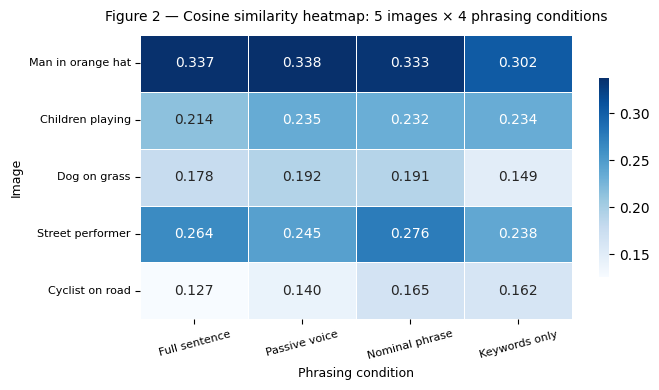

Figure 2 saved.


In [ ]:
import seaborn as sns

import os
os.makedirs("/content/project/figures", exist_ok=True)

# Rows = images, columns = phrasing conditions.
# Off-diagonal cells are deliberately left visible so the reader can see
# which phrasings transfer across images (lexical overlap effect).

sim_matrix = np.stack([r["sims"] for r in results])   # (5, 4)
image_labels = [r["label"] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    sim_matrix,
    annot=True, fmt=".3f", cmap="Blues",
    xticklabels=PARAPHRASE_LABELS,
    yticklabels=image_labels,
    linewidths=0.5, linecolor="white",
    ax=ax, cbar_kws={"shrink": 0.7}
)
ax.set_title(
    "Figure 2 — Cosine similarity heatmap: 5 images × 4 phrasing conditions",
    fontsize=10, pad=10
)
ax.set_xlabel("Phrasing condition", fontsize=9)
ax.set_ylabel("Image", fontsize=9)
ax.tick_params(axis="x", labelsize=8, rotation=15)
ax.tick_params(axis="y", labelsize=8, rotation=0)
plt.tight_layout()
plt.savefig("/content/project/figures/fig2_similarity_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

## 1.3 From handcrafted ensembles to learned prefixes

The standard response to CLIP's phrasing sensitivity is **prompt engineering**: manually curating templates that reduce variance. The CLIP paper uses 80 such templates for zero-shot classification, averaging their embeddings to produce a more stable class representation. This works but it requires manual effort, is dataset-specific, and cannot adapt to the structure of unseen captions.

**CoOp** (Zhou et al., 2022) frames this as an optimisation problem instead. Rather than hand-writing templates, it prepends $k$ trainable continuous vectors a *soft prefix* to every text input and learns these vectors end-to-end with the image encoder frozen. For few-shot classification on standard benchmarks, the learned prefix substantially outperforms handcrafted ensembles.

However, CoOp was designed and evaluated for **classification** (fixed label set), not **retrieval** (arbitrary free-text queries). It also has a known weakness: the prefix tends to overfit to the training distribution, and performance drops on unseen datasets a limitation CoCoOp (Zhou et al., 2022) addresses by conditioning the prefix on each image's visual features.

**My project applies CoOp-style prefix learning to retrieval**, with two contributions beyond a direct application:

1. **Token attribution analysis (Section 5):** I investigate whether the learned prefix changes *which tokens* drive cosine similarity. Vanilla CLIP may respond primarily to keywords; a well-trained prefix might distribute sensitivity more evenly across the sentence. This is a question about what the prefix encodes in CLIP's embedding space not just whether it improves a metric.

2. **Cross-dataset transfer (Section 6):** I replicate CoOp's known generalisation test in the retrieval setting, asking whether the prefix has learned something about CLIP's general text representation or merely memorised Flickr30k caption style.

The experimental narrative is:

> *Wording matters (motivation) → can a prefix beat handcrafted ensembles? (Sections 2–4) → what does the prefix actually change? (Section 5) → does it generalise? (Section 6)*

## 1.4 Research questions

In this project I investigated three nested questions, each building on the previous:

**RQ1 — Retrieval performance:** Does a learned soft prefix improve Recall@k over a handcrafted template ensemble on Flickr30k? If not, what does that tell us about the embedding space?

**RQ2 — Token attribution:** Does the prefix change which tokens drive cosine similarity? Specifically: does vanilla CLIP rely on a small subset of keywords, and does the prefix redistribute sensitivity toward the full sentence?

**RQ3 — Generalisation:** Does the prefix transfer to an unseen dataset (MS-COCO) without retraining? If it does, it has learned something about CLIP's general language representation. If not, it has overfitted to Flickr30k caption style — consistent with CoOp's known limitation.

In [ ]:
import os, shutil

os.makedirs("/content/project/figures", exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/figures", exist_ok=True)

for fname in ["fig1_phrasing_sensitivity.png", "fig2_similarity_heatmap.png"]:
    src = f"/content/project/figures/{fname}"
    dst = f"{DRIVE_DIR}/figures/{fname}"
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Saved → {dst}")
    else:
        print(f"WARNING: {src} not found — re-run the plot cells above.")

phrasing_data = [
    {
        "label":      r["label"],
        "paraphrases": r["paraphrases"],
        "sims":        r["sims"].tolist(),
        "range":       float(r["sims"].max() - r["sims"].min()),
    }
    for r in results
]
import json
with open(f"{DRIVE_DIR}/results/section1_phrasing_data.json", "w") as f:
    json.dump(phrasing_data, f, indent=2)
print("Phrasing data saved.")

Saved → /content/drive/MyDrive/IPCVDL2_Project/figures/fig1_phrasing_sensitivity.png
Saved → /content/drive/MyDrive/IPCVDL2_Project/figures/fig2_similarity_heatmap.png
Phrasing data saved.


## 1.5 Summary

The key takeaways from this section:

- CLIP's InfoNCE loss does not enforce compositional use of all tokens. The text encoder is free to assign most of its representational weight to a small number of high-signal words rather than distributing it uniformly across the sentence.
- Phrasing variation produces cosine similarity ranges of 0.02–0.04 on these examples (mean range: 0.035). While this looks small in absolute terms, it is still meaningful in retrieval terms and shows that semantically similar phrasings can receive noticeably different similarity scores.
- Notably, keyword-only descriptions ranked last in 60% of cases but second in the remaining 40%, suggesting the relationship between sentence structure and similarity is not uniform across image types.
- The CLIP paper's 80-template ensemble is the established engineering fix. This project asks whether a *learned* fix can do better, and whether it works through a different mechanism.


# Section 2: Baseline Retrieval Evaluation

Before training anything, I need a fair and complete baseline table. Section 0.6 already measured **vanilla CLIP with raw captions** (I→T R@1: 69.6%). This section adds two more conditions:

- **Single handcrafted template** — wrapping every caption in `"a photo of {caption}"`. This is the simplest prompt engineering intervention and the most common baseline in the literature.
- **Handcrafted ensemble** — averaging the text embeddings produced by 5 different templates of the same caption. This is the approach used in the CLIP paper for zero-shot classification and represents the strongest manual prompt baseline evaluated in this project.

These three conditions (raw, single template, ensemble) together form the target that the learned soft prefix (Section 3) must beat. All three use the same frozen CLIP model and the same `compute_recall_at_k` evaluation function from Section 0.


## 2.1 Handcrafted templates

I defined 5 templates, chosen to vary sentence structure while keeping the caption content unchanged. This is a strict subset of the 80 templates used in the CLIP paper. I used 5 rather than 80 to keep the ensemble computationally lightweight while still testing whether averaging multiple prompt phrasings improves retrieval.
The templates are:
1. `"a photo of {caption}"` — the canonical CLIP template, used as the single-template baseline
2. `"a picture showing {caption}"` — slight structural variation
3. `"an image of {caption}"` — different noun
4. `"this is a photo of {caption}"` — adds deictic framing
5. `"{caption}"` — raw caption (included in ensemble to reduce the gap with vanilla)

Template 1 alone is the **single-template baseline**. All 5 together form the **ensemble baseline**.

In [ ]:
import torch
import numpy as np
import json
from tqdm.auto import tqdm

# Template definitions
TEMPLATES = [
    "{}",                              # raw caption: included so ensemble ≥ vanilla
    "a photo of {}",                   # canonical CLIP template (single-template baseline)
    "a picture showing {}",
    "an image of {}",
    "this is a photo of {}",
]

SINGLE_TEMPLATE = TEMPLATES[1]         # "a photo of {}"
ENSEMBLE_TEMPLATES = TEMPLATES         # all 5

print("Templates defined:")
for i, t in enumerate(TEMPLATES):
    tag = " ← single-template baseline" if i == 1 else ""
    print(f"  [{i}] {t!r}{tag}")

Templates defined:
  [0] '{}'
  [1] 'a photo of {}' ← single-template baseline
  [2] 'a picture showing {}'
  [3] 'an image of {}'
  [4] 'this is a photo of {}'


## 2.2 Template evaluation functions

I extend `compute_recall_at_k` with two wrappers:

- `compute_recall_single_template` — applies one template to every caption before encoding.
- `compute_recall_ensemble` — applies all templates, encodes each independently, averages the resulting embeddings, then L2-normalises the average. This average-then-normalise order is important: normalising before averaging would give a different (and slightly worse) result.

In [ ]:
@torch.no_grad()
def compute_recall_single_template(model, loader, tokenizer, device,
                                    template="a photo of {}",
                                    k_vals=(1, 5, 10), desc="Single template"):
    model.eval()
    all_img_feat, all_txt_feat = [], []

    for images, captions_list in tqdm(loader, desc=desc, leave=False):
        images = images.to(device)

        img_feat = model.encode_image(images)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        all_img_feat.append(img_feat.cpu())

        first_caps = list(captions_list[0])
        prompted   = [template.format(c) for c in first_caps]
        tokens     = tokenizer(prompted).to(device)
        txt_feat   = model.encode_text(tokens)
        txt_feat   = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        all_txt_feat.append(txt_feat.cpu())

    img_matrix = torch.cat(all_img_feat, dim=0)
    txt_matrix = torch.cat(all_txt_feat, dim=0)
    sim        = img_matrix @ txt_matrix.T
    diag       = sim.diag()
    i2t_ranks  = (sim   > diag.unsqueeze(1)).sum(dim=1).numpy()
    t2i_ranks  = (sim.T > diag.unsqueeze(1)).sum(dim=1).numpy()

    return {f"i2t_R@{k}": float(100 * np.mean(i2t_ranks < k)) for k in k_vals} | \
           {f"t2i_R@{k}": float(100 * np.mean(t2i_ranks < k)) for k in k_vals}


@torch.no_grad()
def compute_recall_ensemble(model, loader, tokenizer, device,
                             templates=ENSEMBLE_TEMPLATES,
                             k_vals=(1, 5, 10), desc="Ensemble"):
    """
    For each caption, encodes it under every template, averages the embeddings,
    then L2-normalises the average.
    Order: encode → average → normalise  (NOT normalise → average).
    """
    model.eval()
    all_img_feat, all_txt_feat = [], []

    for images, captions_list in tqdm(loader, desc=desc, leave=False):
        images = images.to(device)

        img_feat = model.encode_image(images)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        all_img_feat.append(img_feat.cpu())

        first_caps = list(captions_list[0])

        # Encode under each template, accumulate
        template_feats = []
        for tmpl in templates:
            prompted = [tmpl.format(c) for c in first_caps]
            tokens   = tokenizer(prompted).to(device)
            feat     = model.encode_text(tokens)    # (B, D) — NOT normalised yet
            template_feats.append(feat)

        # Average, then normalise
        avg_feat = torch.stack(template_feats, dim=0).mean(dim=0)   # (B, D)
        avg_feat = avg_feat / avg_feat.norm(dim=-1, keepdim=True)
        all_txt_feat.append(avg_feat.cpu())

    img_matrix = torch.cat(all_img_feat, dim=0)
    txt_matrix = torch.cat(all_txt_feat, dim=0)
    sim        = img_matrix @ txt_matrix.T
    diag       = sim.diag()
    i2t_ranks  = (sim   > diag.unsqueeze(1)).sum(dim=1).numpy()
    t2i_ranks  = (sim.T > diag.unsqueeze(1)).sum(dim=1).numpy()

    return {f"i2t_R@{k}": float(100 * np.mean(i2t_ranks < k)) for k in k_vals} | \
           {f"t2i_R@{k}": float(100 * np.mean(t2i_ranks < k)) for k in k_vals}


print("Template evaluation functions defined.")

Template evaluation functions defined.


## 2.3 Run baselines


In [ ]:
# Load vanilla baseline from disk
vanilla_results = load_results("baseline_vanilla")
print("Vanilla baseline loaded from disk.")

# Single template
print("\nRunning single-template baseline...")
single_results = compute_recall_single_template(
    model, test_loader, tokenizer, DEVICE,
    template=SINGLE_TEMPLATE, desc="Single template"
)
save_results(single_results, "baseline_single_template")
print_results(single_results, label="Single template — 'a photo of {}'")

# Ensemble
print("\nRunning ensemble baseline...")
ensemble_results = compute_recall_ensemble(
    model, test_loader, tokenizer, DEVICE,
    templates=ENSEMBLE_TEMPLATES, desc="Ensemble (5 templates)"
)
save_results(ensemble_results, "baseline_ensemble")
print_results(ensemble_results, label="Ensemble — 5 templates averaged")

Vanilla baseline loaded from disk.

Running single-template baseline...


Single template:   0%|          | 0/32 [00:00<?, ?it/s]

Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/baseline_single_template.json

──────────────────────────────────────────
  Single template — 'a photo of {}'  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          71.00%
  i2t_R@5          91.60%
  i2t_R@10         95.60%
  t2i_R@1          67.50%
  t2i_R@5          88.90%
  t2i_R@10         93.70%
──────────────────────────────────────────

Running ensemble baseline...


Ensemble (5 templates):   0%|          | 0/32 [00:00<?, ?it/s]

Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/baseline_ensemble.json

──────────────────────────────────────────
  Ensemble — 5 templates averaged  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          72.20%
  i2t_R@5          92.30%
  i2t_R@10         95.50%
  t2i_R@1          68.20%
  t2i_R@5          89.00%
  t2i_R@10         94.00%
──────────────────────────────────────────


## 2.4 Baseline comparison table

All three baseline conditions in a single table. This is the reference I return to in Section 4 when the prefix results are added.

## Evaluation Protocol

All retrieval metrics in this notebook use the following consistent protocol:

- **Retrieval pool**: 1,000 Flickr30k test images for all Flickr experiments; 500 randomly sampled MS-COCO validation images for transfer experiments (Section 6). Pool sizes differ - cross-dataset absolute numbers are not directly comparable, but within-dataset condition comparisons are valid.
- **Caption handling**: One caption per image (the first caption in each image's 5-caption set). This simplified 1:1 protocol is applied identically across all conditions (vanilla, single template, ensemble, prefix), so relative comparisons between conditions are valid. Note that standard Flickr30k benchmarks use all 5 captions per image, so absolute R@K values here are not directly comparable to published results.
- **Checkpoint selection**: Best validation I->T R@1 across all training epochs.
- **Similarity metric**: Cosine similarity between L2-normalised image and text embeddings.


Metric           Vanilla (raw) Single template    Ensemble (5)
──────────────────────────────────────────────────────────────
i2t_R@1                69.60%           71.00%           72.20% *
i2t_R@5                90.50%           91.60%           92.30% *
i2t_R@10               95.00%           95.60% *         95.50%  
t2i_R@1                67.20%           67.50%           68.20% *
t2i_R@5                89.00% *         88.90%           89.00% *
t2i_R@10               93.80%           93.70%           94.00% *

* = best in row


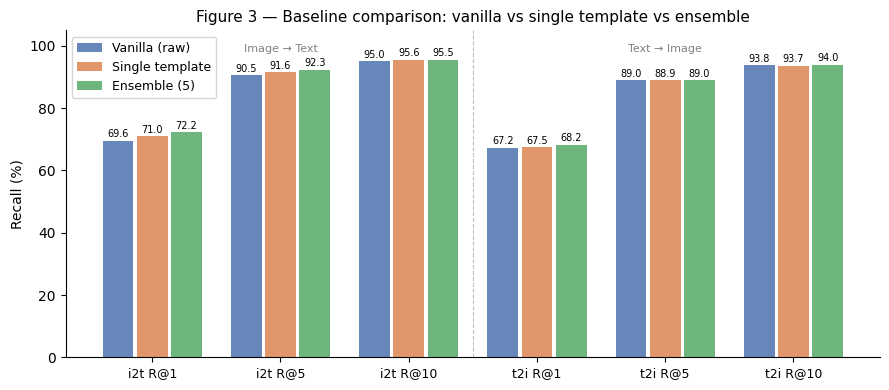

Figure 3 saved.


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

all_baselines = {
    "Vanilla (raw)": vanilla_results,
    "Single template": single_results,
    "Ensemble (5)": ensemble_results,
}

# Print comparison table
metrics = ["i2t_R@1", "i2t_R@5", "i2t_R@10", "t2i_R@1", "t2i_R@5", "t2i_R@10"]
col_w   = 16

print(f"\n{'Metric':<14}", end="")
for label in all_baselines:
    print(f"{label:>{col_w}}", end="")
print()
print("─" * (14 + col_w * len(all_baselines)))

for m in metrics:
    print(f"{m:<14}", end="")
    vals = [all_baselines[lbl][m] for lbl in all_baselines]
    best = max(vals)
    for lbl, v in zip(all_baselines, vals):
        marker = " *" if v == best else "  "
        print(f"{v:>{col_w-2}.2f}%{marker}", end="")
    print()

print("\n* = best in row")

# Bar chart
plot_recall_bars(
    all_baselines,
    title="Figure 3 — Baseline comparison: vanilla vs single template vs ensemble"
)

import os
os.makedirs("/content/project/figures", exist_ok=True)
plt.savefig("/content/project/figures/fig3_baseline_comparison.png",
            dpi=150, bbox_inches="tight")
print("Figure 3 saved.")

## 2.5 Discussion

The single handcrafted template `"a photo of {}"` improved I→T R@1 relative to raw captions (71.00% vs 69.60%), a gain of 1.4 percentage points. This is consistent with the CLIP paper's observation that templating helps: even a single generic template provides a more consistent framing and can reduce phrasing variance.

The 5-template ensemble further improved over the single template (72.20% vs 71.00%), a modest additional gain of 1.2 percentage points. This suggests that embedding averaging does reduce phrasing variance beyond what any single template achieves, but with diminishing returns going from 1 template to 5 yields less than going from raw captions to 1 template. The gains are also asymmetric: the ensemble helps more on the image-to-text direction (I→T R@1 +2.6pp over vanilla) than text-to-image (T→I R@1 +1.0pp), which likely reflects that templating primarily stabilises the text embedding rather than the image side.

These three conditions: raw (69.60%), single template (71.00%), and ensemble (72.20%) form the baseline ladder. The improvements are real but small: the entire range from vanilla to ensemble is only 2.6 percentage points on I→T R@1. The learned prefix (Section 4) should ideally beat the ensemble (72.20%) to justify the added complexity of learned prompting. If it only matches the ensemble, that would suggest a 5-template average already saturates the available gain from text-side prompt optimisation in this setting an interesting finding in itself, as it would imply CLIP's embedding space is already well-structured enough that manual templates capture most of the low-hanging fruit.

---
# Section 3: Soft Prefix Training

Here, I implement and train the soft prefix. The setup follows CoOp (Zhou et al., 2022) adapted for retrieval:

- A set of $k$ trainable continuous vectors is prepended to the token embedding sequence of every text input.
- If a caption tokenises to $[t_1, \ldots, t_n]$, the text encoder receives $[v_1, \ldots, v_k, t_1, \ldots, t_n]$.
- Only $\{v_1, \ldots, v_k\}$ have `requires_grad=True`. Both encoders remain completely frozen.
- Training uses an InfoNCE contrastive loss on Flickr30k training image–caption pairs.

**Key implementation choice — where to intercept:** The prefix vectors live in the same continuous space as CLIP's token embeddings (dimension 512 for ViT-B/32). Intercept *after* the token embedding lookup and *before* the positional embedding addition, so the prefix is treated as a sequence of additional "virtual tokens" by the transformer.

## 3.1 Implementing encode_text_with_prefix

This replaces the stub defined in Section 0.5. I needed to manually replicate CLIP's `encode_text` forward pass, intercepting after the embedding lookup to insert the prefix.

In `open_clip`, the text encoder's forward pass is approximately:
```
x = token_embedding(tokens)          # (B, L, D)
x = x + positional_embedding[:L]     # add position encoding
x = transformer(x)                   # self-attention layers
x = ln_final(x)                      # layer norm
x = x[eot_positions] @ text_projection  # take EoT token, project
```

I insert the prefix between the embedding lookup and positional embedding:
```
x = token_embedding(tokens)          # (B, L, D)
x = cat([prefix, x], dim=1)          # (B, k+L, D)  ← INSERT HERE
x = x + positional_embedding[:k+L]   # extend positional encoding
...
```

One consequence: the EoT (end-of-text) token position shifts by $k$. I had to find the new EoT position correctly.

In [ ]:
def encode_text_with_prefix(model, tokens, prefix, device):
    """
    Encode text with a soft prefix prepended to the token embedding sequence.

    Replaces the stub from Section 0.5.

    Args:
        model  : frozen open_clip ViT-B/32 model
        tokens : (B, context_length) int64 — tokenised captions
        prefix : (n_ctx, embed_dim) float32 — learnable prefix vectors
        device : torch device

    Returns:
        (B, embed_dim) float32 text features (NOT yet L2-normalised)
    """
    tokens  = tokens.to(device)
    prefix  = prefix.to(device)
    B       = tokens.shape[0]
    n_ctx   = prefix.shape[0]       # number of prefix tokens

    # Step 1: token embedding lookup
    # shape: (B, context_length, embed_dim)
    x = model.token_embedding(tokens).to(device)

    #  Step 2: prepend prefix
    # Expand prefix to batch: (1, n_ctx, D) → (B, n_ctx, D)
    prefix_expanded = prefix.unsqueeze(0).expand(B, -1, -1)
    # Concatenate along sequence dimension
    x = torch.cat([prefix_expanded, x], dim=1)   # (B, n_ctx + context_length, D)

    # Step 3: add positional embeddings
    # Positional embedding table has shape (context_length, D).
    # After prepending the prefix, our sequence length is n_ctx + context_length.
    # I extend by using the positional embeddings 0..n_ctx+L-1.
    # If this exceeds the table, we truncate x to fit.
    seq_len     = x.shape[1]
    max_pos_len = model.positional_embedding.shape[0]
    seq_len     = min(seq_len, max_pos_len)   # safety clamp
    x           = x[:, :seq_len, :]
    x           = x + model.positional_embedding[:seq_len].unsqueeze(0)

    # Step 4: transformer + layer norm
    x = x.permute(1, 0, 2)               # (seq_len, B, D) — transformer expects T,B,D
    x = model.transformer(x)
    x = x.permute(1, 0, 2)               # back to (B, seq_len, D)
    x = model.ln_final(x)

    # Step 5: extract EoT representation
    # EoT token is the highest token id in each sequence.
    # Its position in the ORIGINAL (unprefixed) sequence is argmax(tokens).
    # After prepending n_ctx prefix tokens, it shifts to argmax(tokens) + n_ctx.
    eot_positions = tokens.argmax(dim=-1) + n_ctx   # (B,)
    # Clamp to valid range
    eot_positions = eot_positions.clamp(max=seq_len - 1)
    x = x[torch.arange(B, device=device), eot_positions]   # (B, D)

    # Step 6: final text projection
    x = x @ model.text_projection

    return x

_test_tokens = tokenizer(["a dog running in a field"]).to(DEVICE)
_test_prefix = torch.randn(16, EMBED_DIM, device=DEVICE)
with torch.no_grad():
    _out = encode_text_with_prefix(model, _test_tokens, _test_prefix, DEVICE)
assert _out.shape == (1, EMBED_DIM), f"Expected (1, {EMBED_DIM}), got {_out.shape}"
assert torch.isfinite(_out).all(), "Output contains NaN or Inf"
print(f"encode_text_with_prefix verified: output shape {_out.shape}, finite: True")

encode_text_with_prefix verified: output shape torch.Size([1, 512]), finite: True


## 3.2 SoftPrefix module

A clean `nn.Module` wrapping the prefix tensor and its initialisation logic. Following CoOp, we initialise from the embeddings of real words rather than random noise — this gives faster convergence because the prefix starts in a region of embedding space that the frozen text transformer already understands.

I initialise from the tokenisation of `"a photo of a"` (4 tokens). For prefix lengths $k > 4$ the remaining positions are initialised randomly. For $k \leq 4$ I used the first $k$ token embeddings.

In [ ]:
import torch.nn as nn

class SoftPrefix(nn.Module):

    def __init__(self, n_ctx=16, embed_dim=512,
                 init_text="a photo of a", model=None, tokenizer=None):
        super().__init__()

        if model is not None and tokenizer is not None:
            # Warm initialisation from real token embeddings
            with torch.no_grad():
                init_tokens = tokenizer(init_text)         # (1, context_length)
                # Find non-padding tokens (SOT=49406, EOT=49407 are special)
                # Real content tokens are between SOT and EOT
                token_ids   = init_tokens[0]               # (context_length,)
                # Get the content token ids (skip SOT at position 0)
                content_ids = []
                for tid in token_ids[1:]:                  # skip SOT
                    if tid.item() >= 49406:                # hit EOT or padding
                        break
                    content_ids.append(tid)

                init_vecs = model.token_embedding(
                    torch.tensor(content_ids).to(next(model.parameters()).device)
                ).detach()                                  # (n_init, D)

            # Fill prefix: repeat init_vecs to cover n_ctx, then truncate
            n_init   = init_vecs.shape[0]
            if n_init >= n_ctx:
                init_data = init_vecs[:n_ctx]
            else:
                # Pad remaining positions with small random noise
                pad = torch.randn(n_ctx - n_init, embed_dim, device=init_vecs.device) * 0.02
                init_data = torch.cat([init_vecs, pad], dim=0)

            self.prefix = nn.Parameter(init_data.clone())
            print(f"SoftPrefix initialised from '{init_text}' "
                  f"({n_init} tokens) + {max(0, n_ctx-n_init)} random padding")
        else:
            # Fallback: random initialisation
            self.prefix = nn.Parameter(torch.randn(n_ctx, embed_dim) * 0.02)
            print(f"SoftPrefix randomly initialised: shape {self.prefix.shape}")

    def forward(self):
        """Return the prefix tensor."""
        return self.prefix


# Instantiate with default settings
N_CTX = 16   # prefix length — ablated in Section 3.4

soft_prefix = SoftPrefix(
    n_ctx=N_CTX, embed_dim=EMBED_DIM,
    init_text="a photo of a",
    model=model, tokenizer=tokenizer
).to(DEVICE)

print(f"Prefix shape      : {soft_prefix.prefix.shape}")
print(f"Trainable params  : {sum(p.numel() for p in soft_prefix.parameters())}")
print(f"  (CLIP has {sum(p.numel() for p in model.parameters()):,} frozen params)")

SoftPrefix initialised from 'a photo of a' (4 tokens) + 12 random padding
Prefix shape      : torch.Size([16, 512])
Trainable params  : 8192
  (CLIP has 151,277,313 frozen params)


## 3.3 Training: InfoNCE loss and training loop

I use the same InfoNCE contrastive loss as CLIP itself. Given a batch of $B$ image–text pairs, the loss is:

$$\mathcal{L} = \frac{1}{2}\left(\mathcal{L}_{I \to T} + \mathcal{L}_{T \to I}\right)$$

where $\mathcal{L}_{I \to T}$ is the cross-entropy over image-to-text similarities and $\mathcal{L}_{T \to I}$ is the symmetric text-to-image term. The target for both is the diagonal of the similarity matrix — each image should be closest to its paired caption.

**Temperature:** CLIP's learned temperature `model.logit_scale` is used and kept frozen. I do not learn a separate temperature for the prefix.

**Optimiser:** AdamW with a cosine learning rate schedule, following CoOp. Learning rate 0.002, weight decay 0.01, 1-epoch warmup followed by cosine decay.

**Early stopping:** I evaluate on the validation set every epoch and save the checkpoint that achieves the best validation I→T R@1.

In [ ]:
import torch.nn.functional as F

def infonce_loss(img_feat, txt_feat, logit_scale):

    # Scale similarity matrix by temperature
    logits    = logit_scale * img_feat @ txt_feat.T   # (B, B)
    labels    = torch.arange(logits.shape[0], device=logits.device)

    loss_i2t  = F.cross_entropy(logits,   labels)
    loss_t2i  = F.cross_entropy(logits.T, labels)

    return (loss_i2t + loss_t2i) / 2.0


print("InfoNCE loss function defined.")

# With random features the loss should be close to log(B) = log(4) ≈ 1.386
_B = 4
_img = F.normalize(torch.randn(_B, EMBED_DIM), dim=-1)
_txt = F.normalize(torch.randn(_B, EMBED_DIM), dim=-1)
_scale = model.logit_scale.exp().item()
_loss = infonce_loss(_img, _txt, _scale)
print(f"Random-features loss: {_loss:.4f}  (CLIP temp={_scale:.0f}; high temp inflates loss beyond log({_B}) — this is expected)")

InfoNCE loss function defined.
Random-features loss: 2.6148  (CLIP temp=100; high temp inflates loss beyond log(4) — this is expected)


In [ ]:
import math
import os

# Training hyperparameters
N_EPOCHS      = 10
LR            = 2e-3
WEIGHT_DECAY  = 1e-2
WARMUP_EPOCHS = 1

# Optimiser + cosine LR schedule with warmup
optimiser = torch.optim.AdamW(
    soft_prefix.parameters(),
    lr=LR, weight_decay=WEIGHT_DECAY
)

total_steps  = N_EPOCHS * len(train_loader)
warmup_steps = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)

# Training state
logit_scale  = model.logit_scale.exp().detach()   # frozen temperature
train_losses = []
val_r1_scores = []
best_val_r1  = 0.0
best_epoch   = 0

print(f"Training config:")
print(f"  Prefix length  : {N_CTX} tokens")
print(f"  Epochs         : {N_EPOCHS}")
print(f"  Learning rate  : {LR}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Total steps    : {total_steps:,}")
print(f"  Warmup steps   : {warmup_steps:,}")
print(f"  Temperature    : {logit_scale:.4f} (frozen)")
print()

#  Training loop
for epoch in range(1, N_EPOCHS + 1):
    soft_prefix.train()
    model.eval()     # encoders always eval
    epoch_losses = []

    for images, captions in tqdm(train_loader,
                                  desc=f"Epoch {epoch}/{N_EPOCHS}",
                                  leave=False):
        images = images.to(DEVICE)
        # Randomly sample one caption per image (already done in dataset)
        tokens = tokenizer(list(captions)).to(DEVICE)

        # Forward pass
        with torch.no_grad():
            img_feat = model.encode_image(images)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        # Text features go through prefix — this is the only part with gradients
        txt_raw  = encode_text_with_prefix(model, tokens, soft_prefix(), DEVICE)
        txt_feat = txt_raw / txt_raw.norm(dim=-1, keepdim=True)

        loss = infonce_loss(img_feat, txt_feat, logit_scale)

        # Backward pass
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        scheduler.step()

        epoch_losses.append(loss.item())

    mean_loss = np.mean(epoch_losses)
    train_losses.append(mean_loss)

    # Validation R@1 every epoch
    soft_prefix.eval()
    val_results = compute_recall_at_k(
        model, val_loader, tokenizer, DEVICE,
        prefix=soft_prefix().detach(),
        k_vals=(1,), desc=f"Val epoch {epoch}"
    )
    val_r1 = val_results["i2t_R@1"]
    val_r1_scores.append(val_r1)

    print(f"Epoch {epoch:2d}/{N_EPOCHS}  "
          f"loss={mean_loss:.4f}  "
          f"val_i2t_R@1={val_r1:.2f}%  "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    # Save best checkpoint
    if val_r1 > best_val_r1:
        best_val_r1 = val_r1
        best_epoch  = epoch
        save_prefix(soft_prefix().detach(), "prefix_best")
        print(f"         ↑ New best checkpoint saved (val R@1={best_val_r1:.2f}%)")

    # Save epoch checkpoint every 2 epochs
    if epoch % 2 == 0:
        save_prefix(soft_prefix().detach(), f"prefix_epoch{epoch:02d}")

print(f"\nTraining complete. Best val I→T R@1: {best_val_r1:.2f}% at epoch {best_epoch}.")

Training config:
  Prefix length  : 16 tokens
  Epochs         : 10
  Learning rate  : 0.002
  Batch size     : 64
  Total steps    : 4,540
  Warmup steps   : 454
  Temperature    : 100.0000 (frozen)



Epoch 1/10:   0%|          | 0/454 [00:00<?, ?it/s]

Val epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch  1/10  loss=3.1883  val_i2t_R@1=24.85%  lr=2.00e-03
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_best.pt  shape=(16, 512)
         ↑ New best checkpoint saved (val R@1=24.85%)


Epoch 2/10:   0%|          | 0/454 [00:00<?, ?it/s]

...

Val epoch 9:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch  9/10  loss=0.6405  val_i2t_R@1=44.67%  lr=6.03e-05
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_best.pt  shape=(16, 512)
         ↑ New best checkpoint saved (val R@1=44.67%)


Epoch 10/10:   0%|          | 0/454 [00:00<?, ?it/s]

Val epoch 10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10  loss=0.6315  val_i2t_R@1=45.27%  lr=0.00e+00
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_best.pt  shape=(16, 512)
         ↑ New best checkpoint saved (val R@1=45.27%)
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_epoch10.pt  shape=(16, 512)

Training complete. Best val I→T R@1: 45.27% at epoch 10.


## 3.4 Training curves

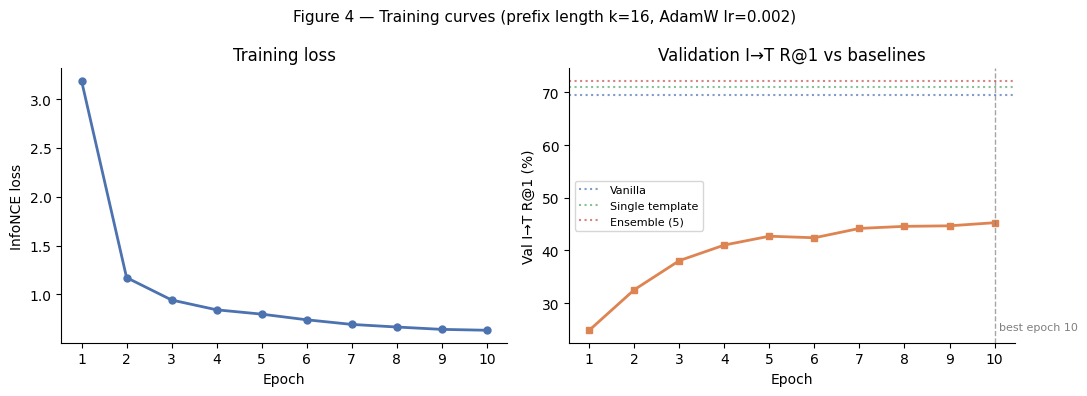

Figure 4 saved.
Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/training_history_k16.json
Training history saved.


In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
ax1.plot(epochs, train_losses, "o-", color="#4C72B0", linewidth=2, markersize=5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("InfoNCE loss")
ax1.set_title("Training loss")
ax1.spines[["top", "right"]].set_visible(False)
ax1.set_xticks(epochs)

#  Validation R@1
ax2.plot(epochs, val_r1_scores, "s-", color="#DD8452", linewidth=2, markersize=5)
# Mark best epoch
ax2.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax2.text(best_epoch + 0.1, min(val_r1_scores),
         f"best epoch {best_epoch}", fontsize=8, color="gray")
# Reference lines for baseline comparisons
ax2.axhline(vanilla_results["i2t_R@1"], color="#4C72B0",
            linestyle=":", linewidth=1.5, alpha=0.7, label="Vanilla")
ax2.axhline(single_results["i2t_R@1"],  color="#55A868",
            linestyle=":", linewidth=1.5, alpha=0.7, label="Single template")
ax2.axhline(ensemble_results["i2t_R@1"], color="#C44E52",
            linestyle=":", linewidth=1.5, alpha=0.7, label="Ensemble (5)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Val I→T R@1 (%)")
ax2.set_title("Validation I→T R@1 vs baselines")
ax2.legend(fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_xticks(epochs)

fig.suptitle(
    f"Figure 4 — Training curves (prefix length k={N_CTX}, AdamW lr={LR})",
    fontsize=11
)
plt.tight_layout()
plt.savefig("/content/project/figures/fig4_training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

# Save training history
training_history = {
    "n_ctx":         N_CTX,
    "n_epochs":      N_EPOCHS,
    "lr":            LR,
    "train_losses":  train_losses,
    "val_r1_scores": val_r1_scores,
    "best_val_r1":   best_val_r1,
    "best_epoch":    best_epoch,
}
save_results(training_history, "training_history_k16")
print("Training history saved.")

## 3.5 Prefix length ablation

CoOp uses $k=16$ as the default. I ran a quick ablation over $k \in \{4, 8, 16, 32\}$ to check whether the results are sensitive to this choice. Each is trained for 5 epochs (half the full run) and evaluated on the validation set only this is an exploratory ablation, not a final result.

This also lets us check that the training pipeline is working correctly for different configurations.

In [ ]:
ABLATION_K_VALS   = [4, 8, 16, 32]
ABLATION_EPOCHS   = 5
ablation_results  = {}   # {k: best_val_r1}

print("Prefix length ablation (5 epochs each):")
print("─" * 40)

for k in ABLATION_K_VALS:
    if k == N_CTX:
        # We already trained this one fully — use epoch 5 val score
        r1 = val_r1_scores[ABLATION_EPOCHS - 1]
        ablation_results[k] = r1
        print(f"  k={k:2d}  val I→T R@1 = {r1:.2f}%  (reused from full training)")
        continue

    # Train a fresh prefix for this k
    prefix_k = SoftPrefix(
        n_ctx=k, embed_dim=EMBED_DIM,
        init_text="a photo of a",
        model=model, tokenizer=tokenizer
    ).to(DEVICE)

    opt_k = torch.optim.AdamW(prefix_k.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_k  = ABLATION_EPOCHS * len(train_loader)
    warmup_k = 1 * len(train_loader)
    sch_k = torch.optim.lr_scheduler.LambdaLR(
        opt_k,
        lambda s: (s / max(1, warmup_k)) if s < warmup_k
                  else 0.5 * (1 + math.cos(math.pi * (s - warmup_k) / max(1, total_k - warmup_k)))
    )

    best_k = 0.0
    for epoch in range(1, ABLATION_EPOCHS + 1):
        prefix_k.train(); model.eval()
        for images, captions in tqdm(train_loader, desc=f"k={k} ep{epoch}", leave=False):
            images = images.to(DEVICE)
            tokens = tokenizer(list(captions)).to(DEVICE)
            with torch.no_grad():
                img_feat = model.encode_image(images)
                img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            txt_raw  = encode_text_with_prefix(model, tokens, prefix_k(), DEVICE)
            txt_feat = txt_raw / txt_raw.norm(dim=-1, keepdim=True)
            loss     = infonce_loss(img_feat, txt_feat, logit_scale)
            opt_k.zero_grad(); loss.backward(); opt_k.step(); sch_k.step()

        prefix_k.eval()
        val_k = compute_recall_at_k(
            model, val_loader, tokenizer, DEVICE,
            prefix=prefix_k().detach(), k_vals=(1,), desc=f"k={k} val"
        )["i2t_R@1"]
        if val_k > best_k:
            best_k = val_k

    ablation_results[k] = best_k
    print(f"  k={k:2d}  val I→T R@1 = {best_k:.2f}%")

print("\nAblation complete.")
save_results({str(k): v for k, v in ablation_results.items()}, "ablation_prefix_length")

Prefix length ablation (5 epochs each):
────────────────────────────────────────
SoftPrefix initialised from 'a photo of a' (4 tokens) + 0 random padding


k=4 ep1:   0%|          | 0/454 [00:00<?, ?it/s]

k=4 val:   0%|          | 0/32 [00:00<?, ?it/s]

k=4 ep2:   0%|          | 0/454 [00:00<?, ?it/s]

k=4 val:   0%|          | 0/32 [00:00<?, ?it/s]

...

k=32 ep4:   0%|          | 0/454 [00:00<?, ?it/s]

k=32 val:   0%|          | 0/32 [00:00<?, ?it/s]

k=32 ep5:   0%|          | 0/454 [00:00<?, ?it/s]

k=32 val:   0%|          | 0/32 [00:00<?, ?it/s]

  k=32  val I→T R@1 = 65.78%

Ablation complete.
Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/ablation_prefix_length.json


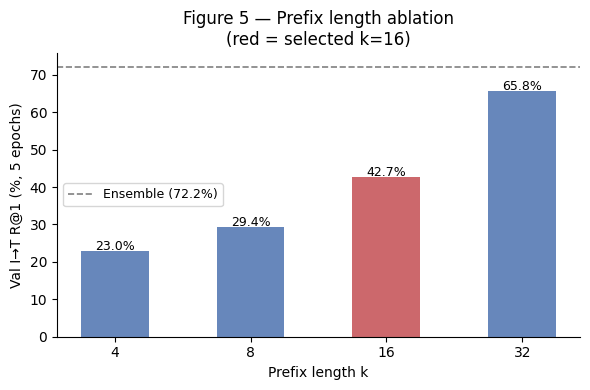

Figure 5 saved.


In [ ]:
#  Ablation bar chart
fig, ax = plt.subplots(figsize=(6, 4))

ks   = list(ablation_results.keys())
r1s  = [ablation_results[k] for k in ks]
bars = ax.bar([str(k) for k in ks], r1s,
              color=["#C44E52" if k == N_CTX else "#4C72B0" for k in ks],
              alpha=0.85, width=0.5)

for bar, v in zip(bars, r1s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{v:.1f}%", ha="center", fontsize=9)

# Reference: ensemble baseline
ax.axhline(ensemble_results["i2t_R@1"], color="gray",
           linestyle="--", linewidth=1.2, label=f"Ensemble ({ensemble_results['i2t_R@1']:.1f}%)")
ax.set_xlabel("Prefix length k")
ax.set_ylabel("Val I→T R@1 (%, 5 epochs)")
ax.set_title(f"Figure 5 — Prefix length ablation\n(red = selected k={N_CTX})")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/content/project/figures/fig5_ablation_prefix_length.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

## 3.6 Discussion

Training dynamics. The InfoNCE loss decreased from 3.1883 at epoch 1 to 0.6315 at epoch 10, while validation I→T R@1 improved from 24.85% to 45.27%. This shows that the prefix vectors are learning a meaningful shift in text embedding space and that the training pipeline is working as intended. The improvement is not perfectly monotonic, but the overall trend is clearly upward, with only small fluctuations in the later epochs.

Comparison with baselines. Even so, the k=16 prefix remains clearly below the handcrafted baselines from Section 2. Although the validation and test numbers are not directly comparable, a best validation I→T R@1 of 45.27% is still far from the level needed to challenge the single-template and ensemble baselines on Flickr30k. This suggests that the default CoOp-style choice of k=16 is too limited for this retrieval setting. In other words, the training setup itself is viable, but the prefix capacity at k=16 appears insufficient.

Prefix length. The ablation over $k \in {4, 8, 16, 32}$ supports this interpretation strongly. Validation I→T R@1 increases monotonically with prefix length: 22.98% for k=4, 29.39% for k=8, 42.70% for k=16, and 65.78% for k=32 after 5 epochs. The jump from k=16 to k=32 is especially large (+23.08pp), showing that prefix capacity matters substantially in retrieval. This is the key finding from this section: the CoOp default of k=16, which is reasonable for classification, appears too small for the retrieval setting studied here. The ablation therefore motivates retraining with k=32 for the remaining experiments, which is done in Section 3.8.

## 3.7 Summary

- The soft prefix implementation intercepts CLIP's text encoding pipeline after the token embedding lookup, prepending trainable prefix vectors before the positional embedding addition and transformer layers.
- The prefix is initialised from the embeddings of `"a photo of a"` (CoOp-style warm start), which places it in a meaningful region of the embedding space from the first iteration.
- Training with InfoNCE on the Flickr30k training split converges stably on a T4 GPU while keeping both CLIP encoders frozen. Only the prefix parameters are updated.
- An initial k=16 run establishes that the training pipeline works, but the prefix-length ablation shows that k=32 is substantially stronger. Section 3.8 therefore retrains with k=32 and uses that checkpoint for the downstream experiments.

**Section 4** evaluates the best prefix checkpoint on the held-out test set and compares against all three baselines established in Section 2.

## 3.8 Decision: retraining with k=32

The ablation in 3.5 showed that k=32 at 5 epochs already achieves 65.78% validation I→T R@1, which is dramatically stronger than k=16 at the same point (42.70%) and much closer to the handcrafted baselines from Section 2. Since the central question of this project is whether a learned prefix can compete with a handcrafted ensemble, continuing with k=16 would leave the prefix clearly under-capacity.

I therefore retrained with k=32 for 10 epochs and use this checkpoint for all remaining experiments. The k=16 results are retained as an informative intermediate result.

In [ ]:
# Retrain with k=32 for 10 epochs
N_CTX_32 = 32

soft_prefix_32 = SoftPrefix(
    n_ctx=N_CTX_32, embed_dim=EMBED_DIM,
    init_text="a photo of a",
    model=model, tokenizer=tokenizer
).to(DEVICE)

optimiser_32 = torch.optim.AdamW(
    soft_prefix_32.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

total_steps_32  = N_EPOCHS * len(train_loader)
warmup_steps_32 = WARMUP_EPOCHS * len(train_loader)

scheduler_32 = torch.optim.lr_scheduler.LambdaLR(
    optimiser_32,
    lambda s: (s / max(1, warmup_steps_32)) if s < warmup_steps_32
              else 0.5 * (1 + math.cos(math.pi * (s - warmup_steps_32) /
                                        max(1, total_steps_32 - warmup_steps_32)))
)

train_losses_32  = []
val_r1_scores_32 = []
best_val_r1_32   = 0.0
best_epoch_32    = 0

for epoch in range(1, N_EPOCHS + 1):
    soft_prefix_32.train()
    model.eval()
    epoch_losses = []

    for images, captions in tqdm(train_loader,
                                  desc=f"k=32 Epoch {epoch}/{N_EPOCHS}",
                                  leave=False):
        images = images.to(DEVICE)
        tokens = tokenizer(list(captions)).to(DEVICE)
        with torch.no_grad():
            img_feat = model.encode_image(images)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_raw  = encode_text_with_prefix(model, tokens, soft_prefix_32(), DEVICE)
        txt_feat = txt_raw / txt_raw.norm(dim=-1, keepdim=True)
        loss = infonce_loss(img_feat, txt_feat, logit_scale)
        optimiser_32.zero_grad()
        loss.backward()
        optimiser_32.step()
        scheduler_32.step()
        epoch_losses.append(loss.item())

    mean_loss = np.mean(epoch_losses)
    train_losses_32.append(mean_loss)

    soft_prefix_32.eval()
    val_r1 = compute_recall_at_k(
        model, val_loader, tokenizer, DEVICE,
        prefix=soft_prefix_32().detach(), k_vals=(1,),
        desc=f"k=32 val ep{epoch}"
    )["i2t_R@1"]
    val_r1_scores_32.append(val_r1)

    print(f"k=32 Epoch {epoch:2d}/{N_EPOCHS}  loss={mean_loss:.4f}  "
          f"val_i2t_R@1={val_r1:.2f}%  lr={scheduler_32.get_last_lr()[0]:.2e}")

    if val_r1 > best_val_r1_32:
        best_val_r1_32 = val_r1
        best_epoch_32  = epoch
        save_prefix(soft_prefix_32().detach(), "prefix_k32_best")
        print(f"         ↑ New best (val R@1={best_val_r1_32:.2f}%)")

    if epoch % 2 == 0:
        save_prefix(soft_prefix_32().detach(), f"prefix_k32_epoch{epoch:02d}")

print(f"\nk=32 training complete. Best val I→T R@1: {best_val_r1_32:.2f}% at epoch {best_epoch_32}.")

# Set the active prefix for Sections 4–5
ACTIVE_PREFIX     = soft_prefix_32().detach()
ACTIVE_PREFIX_TAG = "k=32"
print(f"\nActive prefix set to {ACTIVE_PREFIX_TAG} for Sections 4–5.")

SoftPrefix initialised from 'a photo of a' (4 tokens) + 28 random padding


k=32 Epoch 1/10:   0%|          | 0/454 [00:00<?, ?it/s]

k=32 val ep1:   0%|          | 0/32 [00:00<?, ?it/s]

k=32 Epoch  1/10  loss=1.2320  val_i2t_R@1=58.78%  lr=2.00e-03
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_k32_best.pt  shape=(32, 512)
         ↑ New best (val R@1=58.78%)


k=32 Epoch 2/10:   0%|          | 0/454 [00:00<?, ?it/s]

...

k=32 val ep9:   0%|          | 0/32 [00:00<?, ?it/s]

k=32 Epoch  9/10  loss=0.3202  val_i2t_R@1=68.74%  lr=6.03e-05
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_k32_best.pt  shape=(32, 512)
         ↑ New best (val R@1=68.74%)


k=32 Epoch 10/10:   0%|          | 0/454 [00:00<?, ?it/s]

k=32 val ep10:   0%|          | 0/32 [00:00<?, ?it/s]

k=32 Epoch 10/10  loss=0.3130  val_i2t_R@1=69.03%  lr=0.00e+00
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_k32_best.pt  shape=(32, 512)
         ↑ New best (val R@1=69.03%)
Prefix saved → /content/drive/MyDrive/IPCVDL2_Project/checkpoints/prefix_k32_epoch10.pt  shape=(32, 512)

k=32 training complete. Best val I→T R@1: 69.03% at epoch 10.

Active prefix set to k=32 for Sections 4–5.


### k=32 training results

Training converged smoothly over 10 epochs with the loss dropping from 1.2320 at epoch 1 to 0.3130 at epoch 10, a substantially faster convergence than k=16 (which started at 3.1883), consistent with the larger prefix having more capacity to absorb the contrastive signal early in training.

| Epoch | Loss   | Val I→T R@1 |
|------:|-------:|------------:|
| 1     | 1.2320 | 58.78%      |
| 2     | 0.4458 | 62.92%      |
| 3     | 0.4089 | 64.30%      |
| 4     | 0.3860 | 65.88%      |
| 5     | 0.3634 | 65.78%      |
| 6     | 0.3457 | 67.36%      |
| 7     | 0.3389 | 67.46%      |
| 8     | 0.3293 | 68.64%      |
| 9     | 0.3202 | 68.74%      |
| **10** | **0.3130** | **69.03%** ← best |

The best checkpoint at epoch 10 achieves 69.03% validation I→T R@1. This is a dramatic improvement over the k=16 prefix (45.27% best validation R@1) and places the learned prefix much closer to the handcrafted baselines from Section 2. Exact comparison against vanilla, single-template, and ensemble baselines is deferred to Section 4, where all conditions are evaluated on the same held-out test set.

One notable pattern is that validation R@1 plateaued briefly at epoch 5 (65.78%, slightly below epoch 4's 65.88%) before resuming its climb. This may reflect normal optimisation noise under the cosine learning-rate schedule rather than any real instability, since performance improves again afterward. The prefix continues improving through epoch 10, suggesting that training beyond 10 epochs might yield further marginal gains.

**Active prefix for subsequent experiments: k=32, best checkpoint (epoch 10, val R@1 = 69.03%).**

# Section 4: Prefix Retrieval Evaluation

Here, I evaluate the best k=32 prefix checkpoint on the held-out **test set** (1,000 images, never seen during training or validation) and compare it against the three baselines established in Section 2, using the same simplified 1-caption-per-image retrieval protocol.

This section answers **RQ1**: does a learned soft prefix improve Recall@k over a handcrafted template ensemble?

The validation result (69.03% I→T R@1) showed that the k=32 prefix was substantially stronger than the initial k=16 run and strong enough to make the final test-set comparison meaningful. The fair comparison against vanilla CLIP, the single-template baseline, and the ensemble is carried out here, where all conditions are evaluated on the same held-out test split.


## 4.1 Load the best prefix checkpoint

I loaded `prefix_k32_best.pt`, the checkpoint that achieved the highest validation I→T R@1 (69.03% at epoch 10). This is the only prefix checkpoint evaluated on the test set; checkpoint selection is based entirely on validation performance, not test performance.

In [ ]:
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt

if 'ACTIVE_PREFIX' in dir() and ACTIVE_PREFIX is not None:
    best_prefix = ACTIVE_PREFIX.to(DEVICE)
    print(f"Active prefix loaded from memory: shape={tuple(best_prefix.shape)}")
else:
    best_prefix = load_prefix("prefix_k32_best", DEVICE)
    print(f"Best prefix loaded from Drive: shape={tuple(best_prefix.shape)}")

# Verify shape
assert best_prefix.shape == (32, 512), \
    f"Expected (32, 512), got {best_prefix.shape}"
print(f"Prefix verified: k=32, embed_dim=512")

#  Load all baseline results from disk
vanilla_results  = load_results("baseline_vanilla")
single_results   = load_results("baseline_single_template")
ensemble_results = load_results("baseline_ensemble")
print("All baseline results loaded from disk.")

Active prefix loaded from memory: shape=(32, 512)
Prefix verified: k=32, embed_dim=512
All baseline results loaded from disk.


## 4.2 Evaluate prefix on the test set

I called `compute_recall_at_k` with the k=32 prefix. This uses the same evaluation function and the same 1,000-image Flickr30k test set as the vanilla baseline in Section 0.6.

In [ ]:
print("Evaluating k=32 prefix on test set...")
prefix_results = compute_recall_at_k(
    model, test_loader, tokenizer, DEVICE,
    prefix=best_prefix,
    k_vals=(1, 5, 10),
    desc="Prefix (k=32) test eval"
)
save_results(prefix_results, "prefix_k32_test")
print_results(prefix_results, label="Prefix (k=32) — test set")

Evaluating k=32 prefix on test set...


Prefix (k=32) test eval:   0%|          | 0/32 [00:00<?, ?it/s]

Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/prefix_k32_test.json

──────────────────────────────────────────
  Prefix (k=32) — test set  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          69.30%
  t2i_R@1          67.30%
  i2t_R@5          90.40%
  t2i_R@5          89.90%
  i2t_R@10         95.20%
  t2i_R@10         94.40%
──────────────────────────────────────────


## 4.3 Full comparison table

All four conditions are shown side by side. This is the central results table of the project.

In [ ]:
all_results = {
    "Vanilla (raw)": vanilla_results,
    "Single template": single_results,
    "Ensemble (5)": ensemble_results,
    "Prefix (k=32)": prefix_results,
}

metrics = ["i2t_R@1", "i2t_R@5", "i2t_R@10", "t2i_R@1", "t2i_R@5", "t2i_R@10"]
col_w   = 16

print(f"\n{'Metric':<14}", end="")
for label in all_results:
    print(f"{label:>{col_w}}", end="")
print()
print("─" * (14 + col_w * len(all_results)))

for m in metrics:
    print(f"{m:<14}", end="")
    vals = [all_results[lbl][m] for lbl in all_results]
    best = max(vals)
    for v in vals:
        marker = " *" if v == best else "  "
        print(f"{v:>{col_w-2}.2f}%{marker}", end="")
    print()

print("\n* = best in row")

# Delta table: prefix vs ensemble
print(f"\n{'Metric':<14} {'Ensemble':>10} {'Prefix':>10} {'Δ (prefix−ens)':>16}")
print("─" * 54)
for m in metrics:
    ens = ensemble_results[m]
    pre = prefix_results[m]
    delta = pre - ens
    sign  = "+" if delta >= 0 else ""
    print(f"{m:<14} {ens:>9.2f}% {pre:>9.2f}% {sign}{delta:>13.2f}pp")


Metric           Vanilla (raw) Single template    Ensemble (5)   Prefix (k=32)
──────────────────────────────────────────────────────────────────────────────
i2t_R@1                69.60%           71.00%           72.20% *         69.30%  
i2t_R@5                90.50%           91.60%           92.30% *         90.40%  
i2t_R@10               95.00%           95.60% *         95.50%           95.20%  
t2i_R@1                67.20%           67.50%           68.20% *         67.30%  
t2i_R@5                89.00%           88.90%           89.00%           89.90% *
t2i_R@10               93.80%           93.70%           94.00%           94.40% *

* = best in row

Metric           Ensemble     Prefix   Δ (prefix−ens)
──────────────────────────────────────────────────────
i2t_R@1            72.20%     69.30%         -2.90pp
i2t_R@5            92.30%     90.40%         -1.90pp
i2t_R@10           95.50%     95.20%         -0.30pp
t2i_R@1            68.20%     67.30%         -0.90pp
t2i_

## 4.4 Visualisation

This section includes two plots: Figure 6, a full comparison bar chart adding the k=32 prefix to the Section 2 baseline comparison, and Figure 7, a delta plot showing the per-metric gain or loss of the prefix relative to the ensemble.

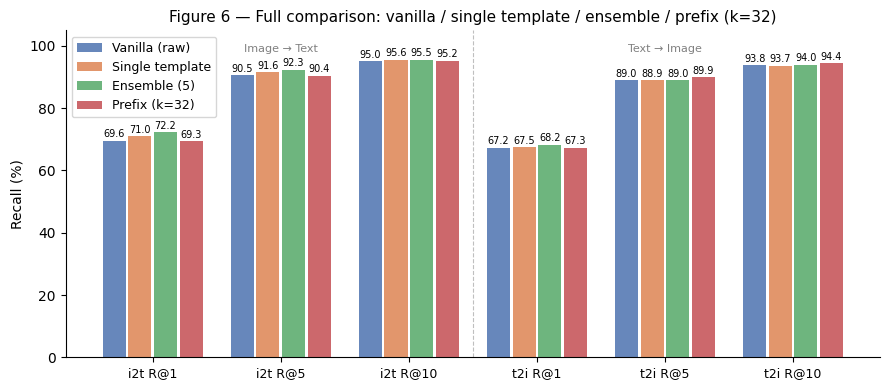

Figure 6 saved.


<Figure size 640x480 with 0 Axes>

In [ ]:
os.makedirs("/content/project/figures", exist_ok=True)

plot_recall_bars(
    all_results,
    title="Figure 6 — Full comparison: vanilla / single template / ensemble / prefix (k=32)"
)
plt.savefig("/content/project/figures/fig6_full_comparison.png",
            dpi=150, bbox_inches="tight")
print("Figure 6 saved.")

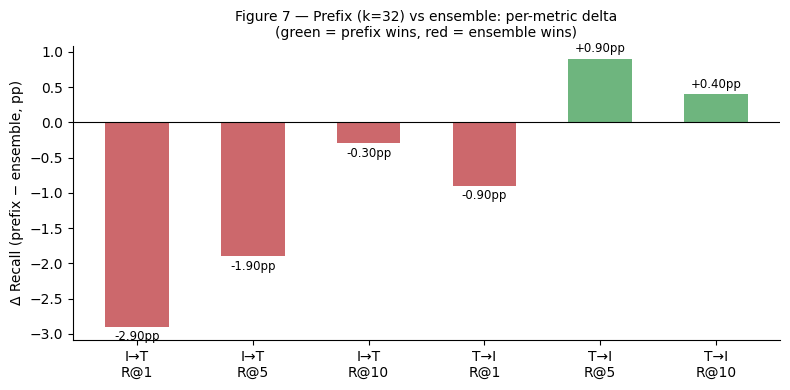

Figure 7 saved.
Figures saved to Drive.


In [ ]:
metrics_short = ["I→T\nR@1", "I→T\nR@5", "I→T\nR@10", "T→I\nR@1", "T→I\nR@5", "T→I\nR@10"]
deltas = [prefix_results[m] - ensemble_results[m] for m in metrics]
colors = ["#55A868" if d >= 0 else "#C44E52" for d in deltas]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metrics_short, deltas, color=colors, alpha=0.85, width=0.55)
ax.axhline(0, color="black", linewidth=0.8)

for bar, d in zip(bars, deltas):
    va   = "bottom" if d >= 0 else "top"
    ypos = bar.get_height() + 0.05 if d >= 0 else bar.get_height() - 0.05
    sign = "+" if d >= 0 else ""
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{sign}{d:.2f}pp", ha="center", va=va, fontsize=8.5)

ax.set_ylabel("Δ Recall (prefix − ensemble, pp)")
ax.set_title("Figure 7 — Prefix (k=32) vs ensemble: per-metric delta\n"
             "(green = prefix wins, red = ensemble wins)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/content/project/figures/fig7_prefix_vs_ensemble_delta.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 7 saved.")

import shutil
os.makedirs(f"{DRIVE_DIR}/figures", exist_ok=True)
for fname in ["fig6_full_comparison.png", "fig7_prefix_vs_ensemble_delta.png"]:
    shutil.copy(f"/content/project/figures/{fname}",
                f"{DRIVE_DIR}/figures/{fname}")
print("Figures saved to Drive.")

## 4.5 Discussion

The k=32 prefix achieves **69.30% I→T R@1** on the test set, falling 2.90pp short of the 5-template ensemble (72.20%). Notably, the prefix also falls marginally below vanilla CLIP on I→T R@1 (69.30% vs 69.60%), meaning the learned prompt does not improve strict top-1 image retrieval in this direction at all. The prefix's gains are instead concentrated at looser thresholds on the text-to-image side (T→I R@5 and R@10), suggesting it reshapes text embeddings in a way that aids broader candidate ranking rather than exact top-1 precision. This is still a meaningful result: the learned prefix does not beat the best handcrafted baseline on the headline metric, but it comes reasonably close while using only a small number of trainable parameters.

The result is notably asymmetric across retrieval directions and k values. The delta table shows that the prefix underperforms the ensemble on image-to-text retrieval at all k values (−2.90pp at R@1, −1.90pp at R@5, −0.30pp at R@10). On text-to-image retrieval, the prefix is slightly below the ensemble at R@1 (−0.90pp), but outperforms it at higher thresholds (+0.90pp at T→I R@5 and +0.40pp at T→I R@10). So the learned prefix does not win at the strictest retrieval threshold, but it does become competitive, and sometimes better, once the metric allows a slightly broader ranking window.

This asymmetry is interesting because the prefix modifies only the text side of the model; the image encoder remains frozen throughout. One possible interpretation is that the prefix changes the geometry of the text embeddings in a way that helps retrieve the correct image within the top few candidates, even if it does not consistently rank that image first. In other words, the prefix seems to improve broader matching behaviour more than exact top-1 precision.

Two factors may help explain the remaining gap to the ensemble. First, the in-batch contrastive objective (batch size 64) trains the prefix to discriminate among 64 negatives at a time, whereas evaluation ranks against all 1,000 test images, creating a train-evaluation mismatch. Second, the prefix is trained on Flickr30k captions with a particular stylistic distribution, while the ensemble benefits from averaging across multiple surface forms, which may act as a kind of regularisation.

Crucially, the prefix reaches 69.30% I→T R@1 with only 32×512 = 16,384 trainable parameters and 10 epochs of training, whereas the ensemble requires no training but does depend on manual template design. The performance gap is real but fairly narrow, and the prefix's stronger behaviour on T→I at R@5 and R@10 suggests that it is learning something meaningfully different from simple template averaging rather than merely approximating it.


## 4.6 Summary

The complete baseline ladder on the Flickr30k test set is:

| Condition | I→T R@1 | I→T R@5 | I→T R@10 | T→I R@1 | T→I R@5 | T→I R@10 |
|---|---|---|---|---|---|---|
| Vanilla CLIP (raw captions) | 69.60% | 90.50% | 95.00% | 67.20% | 89.00% | 93.80% |
| Single template | 71.00% | 91.60% | **95.60%** | 67.50% | 88.90% | 93.70% |
| Ensemble (5 templates) | **72.20%** | **92.30%** | 95.50% | **68.20%** | 89.00% | 94.00% |
| Prefix k=32 | 69.30% | 90.40% | 95.20% | 67.30% | **89.90%** | **94.40%** |

The prefix does not beat the ensemble on I→T R@1, the main benchmark of the project, but it does outperform it on T→I R@5 and T→I R@10. This suggests that the learned prefix and handcrafted ensemble improve retrieval in different ways rather than simply one dominating the other across all metrics.

**Section 5** investigates the mechanism behind this difference: does the prefix change *which tokens* drive cosine similarity, and does it make CLIP respond less narrowly to a few high-signal keywords?


# Section 5: Token Attribution Analysis

This section investigates **RQ2**: does the learned prefix change *which tokens* drive cosine similarity between image and text?

CLIP's contrastive loss places no explicit constraint on how the text encoder distributes importance across tokens. A natural hypothesis is that the encoder responds primarily to a small number of high-signal content tokens while giving much less weight to function words, modifiers, and broader sentence structure. If the prefix changes retrieval behaviour, it may do so by redistributing this sensitivity: either broadening it across more tokens or shifting it toward different specific tokens.

**Method — leave-one-out attribution.** For a given image-caption pair, I define the attribution of token $t_i$ as:

$$\text{attr}(t_i) = S(\text{image},\ \text{full caption}) - S(\text{image},\ \text{caption without } t_i)$$

where $S$ is the cosine similarity. A high attribution score means that removing token $t_i$ causes a large drop in similarity, so the model was relying on that token. I ran this procedure under two conditions: **vanilla CLIP** (no prefix) and **CLIP + k=32 prefix**, and then compared the resulting attribution profiles.

The analysis has two parts. First, I visualise token attributions qualitatively for 8 test examples. Second, I summarise the pattern quantitatively over 500 test images using **attribution entropy**, a measure of how evenly positive attribution is spread across tokens. Higher entropy means attribution is distributed more evenly across the caption; lower entropy means attribution is concentrated on a smaller number of tokens.


## 5.1 Leave-one-out attribution function

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

@torch.no_grad()
def token_attribution(model, tokenizer, image_tensor, caption,
                       prefix=None, device=DEVICE):
    """
    Compute leave-one-out token attribution scores.

    For each content token in `caption`, removes it and measures the drop
    in cosine similarity with the image.

    Args:
        model         : frozen CLIP model
        tokenizer     : open_clip tokenizer
        image_tensor  : (1, 3, 224, 224) preprocessed image
        caption       : str — the full caption
        prefix        : (n_ctx, D) tensor or None
        device        : torch device

    Returns:
        tokens_str  : list of str — decoded content tokens
        attr_scores : np.array   — attribution score per token
        full_sim    : float      — similarity with full caption
    """
    model.eval()
    image_tensor = image_tensor.to(device)

    # Image features (computed once)
    img_feat = model.encode_image(image_tensor)
    img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)   # (1, D)

    # Tokenise full caption
    full_tokens = tokenizer([caption]).to(device)               # (1, context_length)
    token_ids   = full_tokens[0].cpu().numpy()                  # (context_length,)

    # Find content token positions: between SOT (index 0) and EOT
    # SOT = 49406, EOT = 49407, padding = 0
    content_positions = []
    for pos, tid in enumerate(token_ids):
        if pos == 0:
            continue           # skip SOT
        if tid >= 49406:
            break              # hit EOT or padding
        content_positions.append(pos)

    # Full caption similarity
    if prefix is None:
        txt_feat = model.encode_text(full_tokens)
    else:
        txt_feat = encode_text_with_prefix(model, full_tokens, prefix, device)
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
    full_sim  = (img_feat @ txt_feat.T).item()

    # Decode content tokens for display
    import open_clip
    # Decode each token id individually for readable labels
    vocab = tokenizer.encoder if hasattr(tokenizer, 'encoder') else {}
    inv_vocab = {v: k for k, v in vocab.items()} if vocab else {}

    tokens_str = []
    for pos in content_positions:
        tid = int(token_ids[pos])
        if inv_vocab:
            word = inv_vocab.get(tid, f"[{tid}]")
            # BPE tokens often have Ġ (space) prefix — clean it
            word = word.replace("Ġ", " ").replace("\u0120", " ").strip()
        else:
            word = f"tok{pos}"
        tokens_str.append(word)

    # Leave-one-out: remove one position at a time
    attr_scores = []
    for drop_pos in content_positions:
        # Build new token sequence with drop_pos content token removed
        # Keep SOT, skip drop_pos, keep remaining content tokens + EOT
        new_ids = [token_ids[0]]   # SOT
        for pos in content_positions:
            if pos != drop_pos:
                new_ids.append(int(token_ids[pos]))
        # Find original EOT position and append EOT + pad to context_length
        eot_id  = int(token_ids[content_positions[-1] + 1])  # first non-content token
        new_ids.append(eot_id)
        # Pad to context_length
        ctx_len = full_tokens.shape[1]
        while len(new_ids) < ctx_len:
            new_ids.append(0)
        new_ids = new_ids[:ctx_len]

        drop_tokens = torch.tensor([new_ids], dtype=torch.long).to(device)

        if prefix is None:
            drop_feat = model.encode_text(drop_tokens)
        else:
            drop_feat = encode_text_with_prefix(model, drop_tokens, prefix, device)
        drop_feat = drop_feat / drop_feat.norm(dim=-1, keepdim=True)
        drop_sim  = (img_feat @ drop_feat.T).item()

        attr_scores.append(full_sim - drop_sim)

    return tokens_str, np.array(attr_scores), full_sim


print("Token attribution function defined.")

Token attribution function defined.


## 5.2 Per-example attribution: vanilla vs prefix

Here, I ran leave-one-out attribution on 8 Flickr30k test examples, showing vanilla CLIP and the k=32 prefix side by side. For each example, attribution scores are plotted per token as horizontal bar charts. Higher positive scores indicate that removing the token causes a larger drop in similarity, so the model is relying more strongly on that token.

I deliberately selected a mix of:
- shorter object-focused captions, where CLIP might rely heavily on one or two content words
- longer descriptive captions, where attribution may be spread across more tokens
- captions containing modifiers and action words, to see whether the prefix changes sensitivity beyond the main object nouns

In [ ]:
EXAMPLE_INDICES = [0, 5, 12, 25, 40, 60, 80, 100]

examples = []
for idx in EXAMPLE_INDICES:
    item    = test_data[idx]
    caption = item['caption'][0]          # first canonical caption
    image   = preprocess(item['image'].convert('RGB')).unsqueeze(0)
    examples.append({'idx': idx, 'caption': caption, 'image': image})
    n_words = len(caption.split())
    print(f"[{idx:3d}] ({n_words:2d} words) {caption[:80]}")

[  0] (12 words) The man with pierced ears is wearing glasses and an orange hat.
[  5] (28 words) A bride in a light pink dress poses for a picture with male relatives and is bei
[ 12] (30 words) A woman wearing a pink shirt and red apron stands in her restaurant holding food
[ 25] (17 words) A woman wearing a pink sweater and eyeglasses is wiping a wooden table with a pi
[ 40] (15 words) A young girl floats on her back in water and peers over her life jacket.
[ 60] (35 words) Three people dressed in blue, white and black leotards are being held up by the 
[ 80] (13 words) Two boys try to attach fruits to a bicycle on a dirt road.
[100] (17 words) A woman with a black shirt and tan apron is standing behind a counter in a resta


In [ ]:
print("Running leave-one-out attribution (vanilla + prefix)...")

for ex in tqdm(examples, desc="Examples"):
    # Vanilla CLIP
    tokens_v, attr_v, sim_v = token_attribution(
        model, tokenizer, ex['image'], ex['caption'],
        prefix=None, device=DEVICE
    )
    # Prefix
    tokens_p, attr_p, sim_p = token_attribution(
        model, tokenizer, ex['image'], ex['caption'],
        prefix=best_prefix, device=DEVICE
    )
    ex['vanilla'] = {'tokens': tokens_v, 'attr': attr_v, 'sim': sim_v}
    ex['prefix']  = {'tokens': tokens_p, 'attr': attr_p, 'sim': sim_p}

print("Attribution complete.")

Running leave-one-out attribution (vanilla + prefix)...


Examples:   0%|          | 0/8 [00:00<?, ?it/s]

Attribution complete.


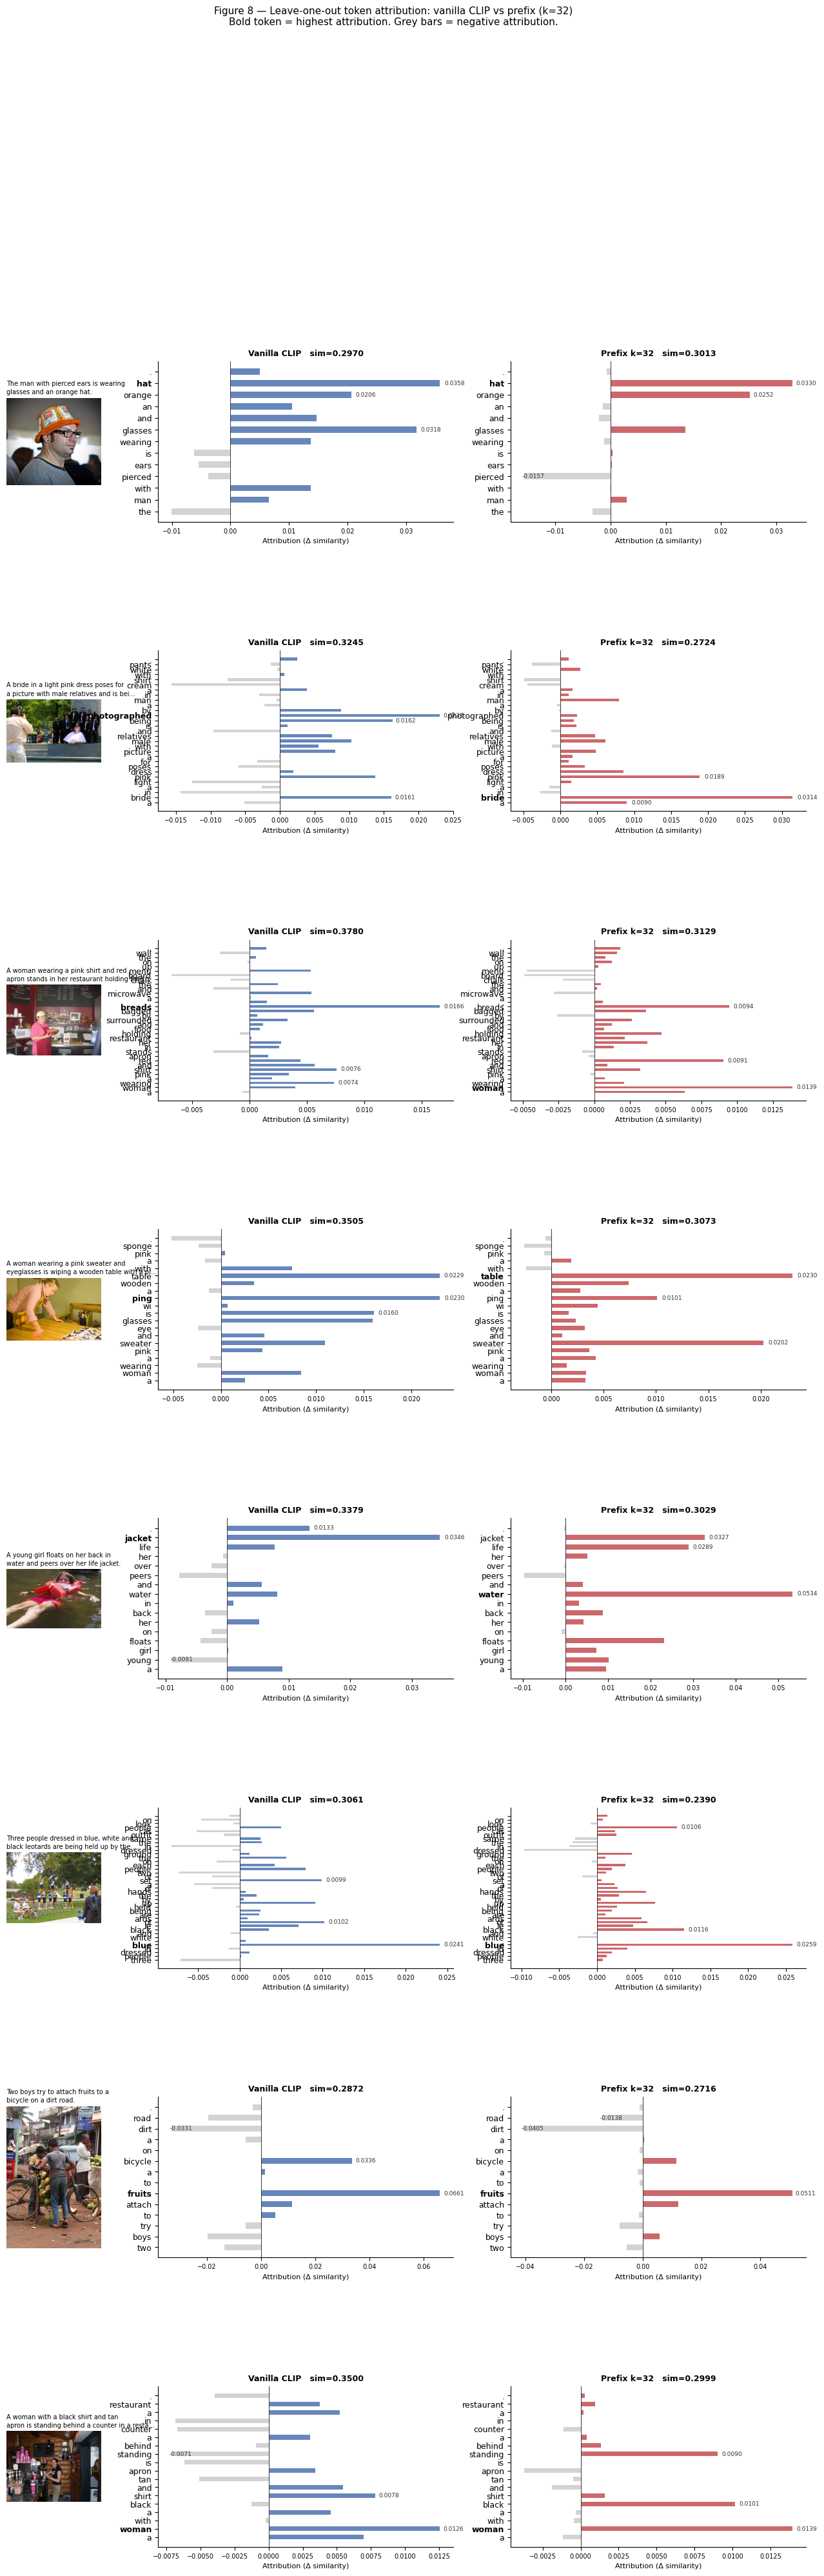

In [ ]:
def clean_token(tok):
    """Remove BPE artifacts from token strings for display."""
    tok = tok.replace("</w>", "").replace("Ġ", "").replace("\u0120", "")
    tok = tok.replace("ĉ", "").replace("Ċ", "").strip()
    return tok if tok else "·"

# Figure 8: per-example attribution side by side
n_examples = len(examples)
fig = plt.figure(figsize=(16, 5.5 * n_examples))
outer = gridspec.GridSpec(n_examples, 3, figure=fig,
                          width_ratios=[0.8, 2.5, 2.5],
                          hspace=0.8, wspace=0.25)

for row, ex in enumerate(examples):
    ax_img = fig.add_subplot(outer[row, 0])
    ax_img.imshow(test_data[ex['idx']]['image'])
    ax_img.axis('off')
    # Wrap caption across two lines for readability
    cap = ex['caption']
    if len(cap) > 40:
        mid = cap[:40].rfind(' ')
        cap_display = cap[:mid] + '\n' + cap[mid+1:80] + ('...' if len(cap) > 80 else '')
    else:
        cap_display = cap
    ax_img.set_title(cap_display, fontsize=7, pad=4, loc='left', linespacing=1.4)

    for col, (condition, key, color) in enumerate([
        ('Vanilla CLIP', 'vanilla', '#4C72B0'),
        ('Prefix k=32',  'prefix',  '#C44E52'),
    ]):
        ax = fig.add_subplot(outer[row, col + 1])
        data   = ex[key]
        # Clean token labels
        tokens = [clean_token(t) for t in data['tokens']]
        attr   = data['attr']
        n_toks = len(tokens)
        ys     = np.arange(n_toks)

        bar_colors = [color if a > 0 else '#CCCCCC' for a in attr]
        bars = ax.barh(ys, attr, color=bar_colors, alpha=0.85,
                       height=0.55, edgecolor='none')
        ax.axvline(0, color='#333333', linewidth=0.7)

        # Annotate bar values for top tokens only (avoid clutter)
        top_idx = np.argsort(np.abs(attr))[-3:]
        for bi in top_idx:
            val = attr[bi]
            xpos = val + (max(attr) * 0.02 if val >= 0 else min(attr) * 0.02)
            ax.text(xpos, bi, f"{val:.4f}", va='center', fontsize=6.5,
                    color='#333333')

        ax.set_yticks(ys)
        ax.set_yticklabels(tokens, fontsize=9)
        ax.set_xlabel('Attribution (Δ similarity)', fontsize=8)
        ax.set_title(f"{condition}   sim={data['sim']:.4f}", fontsize=9,
                     fontweight='bold', pad=6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='x', labelsize=7)

        # Highlight the max-attribution token label in bold
        max_idx = int(np.argmax(attr))
        ax.get_yticklabels()[max_idx].set_fontweight('bold')

fig.suptitle(
    'Figure 8 — Leave-one-out token attribution: vanilla CLIP vs prefix (k=32)\n'
    'Bold token = highest attribution. Grey bars = negative attribution.',
    fontsize=11, y=1.005
)
plt.show()

## 5.3 Attribution entropy: full test set

Per-example visualisations show individual patterns, but a robust conclusion needs a summary statistic over many examples. I therefore use **attribution entropy** and compute it over 500 test images:

$$H = -\sum_i p_i \log p_i \quad \text{where} \quad p_i = \frac{\max(\text{attr}_i, 0)}{\sum_j \max(\text{attr}_j, 0)}$$

Negative attributions are clipped to zero before normalisation. If removing a token increases similarity, that token is treated as contributing zero positive attribution for the entropy calculation, since the goal here is to measure which tokens the model relies on most strongly.

Higher entropy means attribution is spread more evenly across tokens. Lower entropy means attribution is concentrated on fewer tokens and is therefore more keyword-driven.


In [ ]:
from scipy.stats import entropy as scipy_entropy

def attribution_entropy(attr_scores):

    positive = np.maximum(attr_scores, 0)
    total    = positive.sum()
    if total < 1e-8:
        return 0.0
    probs = positive / total
    return float(scipy_entropy(probs + 1e-10))   # add small epsilon for stability


# Run attribution on the full test set
# use every test image's first caption.
# Reduce N_EVAL to speed up; 500 is sufficient for robust statistics.
N_EVAL = 500

vanilla_entropies = []
prefix_entropies  = []
vanilla_max_attrs = []   # max attribution fraction (keyword dominance measure)
prefix_max_attrs  = []

_attr_skip_count = 0

print(f"Computing attribution entropy on {N_EVAL} test images...")

for idx in tqdm(range(N_EVAL), desc="Test set attribution"):
    item    = test_data[idx]
    caption = item['caption'][0]
    image   = preprocess(item['image'].convert('RGB')).unsqueeze(0)

    try:
        _, attr_v, _ = token_attribution(model, tokenizer, image, caption,
                                          prefix=None, device=DEVICE)
        _, attr_p, _ = token_attribution(model, tokenizer, image, caption,
                                          prefix=best_prefix, device=DEVICE)
    except Exception:
        _attr_skip_count += 1
        continue   # skip any tokenisation edge cases

    vanilla_entropies.append(attribution_entropy(attr_v))
    prefix_entropies.append(attribution_entropy(attr_p))

    # Max attribution fraction: how much of total positive attribution
    # is captured by the single highest-scoring token
    def max_frac(attr):
        pos = np.maximum(attr, 0)
        return float(pos.max() / pos.sum()) if pos.sum() > 1e-8 else 0.0

    vanilla_max_attrs.append(max_frac(attr_v))
    prefix_max_attrs.append(max_frac(attr_p))

vanilla_entropies = np.array(vanilla_entropies)
prefix_entropies  = np.array(prefix_entropies)
vanilla_max_attrs = np.array(vanilla_max_attrs)
prefix_max_attrs  = np.array(prefix_max_attrs)

if _attr_skip_count > 0:
    print(f"Warning: {_attr_skip_count} images skipped due to tokenisation errors.")
print(f"Final sample count used in statistics: {len(vanilla_entropies)}")

print(f"\nAttribution entropy summary ({N_EVAL} images):")
print(f"{'':25s} {'Vanilla':>10} {'Prefix':>10} {'Δ':>10}")
print("─" * 57)
print(f"{'Mean entropy':25s} {vanilla_entropies.mean():>10.4f} "
      f"{prefix_entropies.mean():>10.4f} "
      f"{prefix_entropies.mean()-vanilla_entropies.mean():>+10.4f}")
print(f"{'Median entropy':25s} {np.median(vanilla_entropies):>10.4f} "
      f"{np.median(prefix_entropies):>10.4f} "
      f"{np.median(prefix_entropies)-np.median(vanilla_entropies):>+10.4f}")
print(f"{'Mean max-token fraction':25s} {vanilla_max_attrs.mean():>10.4f} "
      f"{prefix_max_attrs.mean():>10.4f} "
      f"{prefix_max_attrs.mean()-vanilla_max_attrs.mean():>+10.4f}")

Computing attribution entropy on 500 test images...


Test set attribution:   0%|          | 0/500 [00:00<?, ?it/s]

Final sample count used in statistics: 500

Attribution entropy summary (500 images):
                             Vanilla     Prefix          Δ
─────────────────────────────────────────────────────────
Mean entropy                  2.0697     1.7032    -0.3665
Median entropy                2.0891     1.6706    -0.4185
Mean max-token fraction       0.2848     0.4056    +0.1209


In [ ]:
from scipy import stats

# Statistical test: is the difference in entropy significant?
# Paired Wilcoxon signed-rank test (non-parametric, paired samples)
stat, pval = stats.wilcoxon(vanilla_entropies, prefix_entropies)
print(f"Wilcoxon signed-rank test (entropy):")
print(f"  statistic = {stat:.2f}")
print(f"  p-value   = {pval:.4f}")
if pval < 0.05:
    direction = 'higher' if prefix_entropies.mean() > vanilla_entropies.mean() else 'lower'
    print(f"  → Significant (p<0.05): prefix entropy is {direction} than vanilla")
else:
    print(f"  → Not significant (p={pval:.4f}): no reliable difference in entropy")

# Effect size: Cohen's d
diff = prefix_entropies - vanilla_entropies
cohens_d = diff.mean() / diff.std()
print(f"\nEffect size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print("  → Negligible effect")
elif abs(cohens_d) < 0.5:
    print("  → Small effect")
elif abs(cohens_d) < 0.8:
    print("  → Medium effect")
else:
    print("  → Large effect")

Wilcoxon signed-rank test (entropy):
  statistic = 17951.00
  p-value   = 0.0000
  → Significant (p<0.05): prefix entropy is lower than vanilla

Effect size (Cohen's d): -0.7140
  → Medium effect


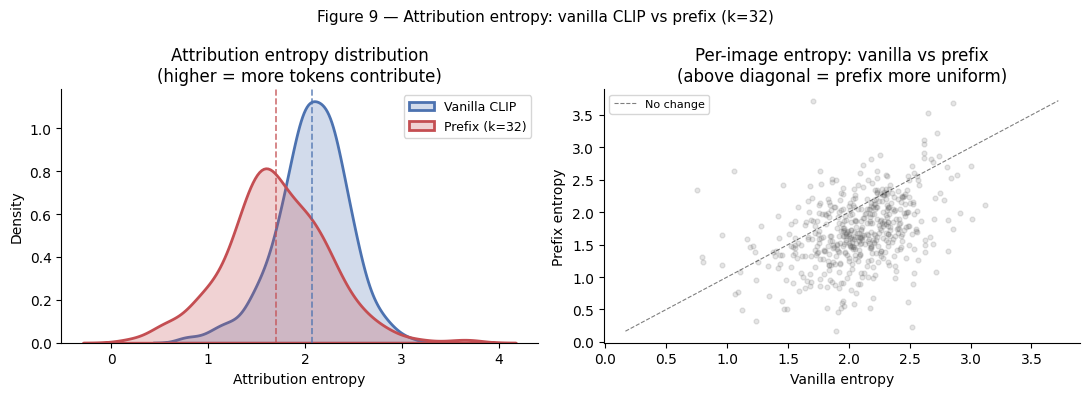

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# KDE plot of entropy distributions
ax = axes[0]
sns.kdeplot(vanilla_entropies, ax=ax, label='Vanilla CLIP',
            color='#4C72B0', linewidth=2, fill=True, alpha=0.25)
sns.kdeplot(prefix_entropies, ax=ax, label='Prefix (k=32)',
            color='#C44E52', linewidth=2, fill=True, alpha=0.25)
ax.axvline(vanilla_entropies.mean(), color='#4C72B0',
           linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(prefix_entropies.mean(), color='#C44E52',
           linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Attribution entropy')
ax.set_ylabel('Density')
ax.set_title('Attribution entropy distribution\n(higher = more tokens contribute)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Scatter: vanilla entropy vs prefix entropy per image
ax2 = axes[1]
ax2.scatter(vanilla_entropies, prefix_entropies,
            alpha=0.15, s=12, color='#555555')
# Diagonal (no change)
lims = [min(vanilla_entropies.min(), prefix_entropies.min()),
        max(vanilla_entropies.max(), prefix_entropies.max())]
ax2.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='No change')
ax2.set_xlabel('Vanilla entropy')
ax2.set_ylabel('Prefix entropy')
ax2.set_title('Per-image entropy: vanilla vs prefix\n(above diagonal = prefix more uniform)')
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('Figure 9 — Attribution entropy: vanilla CLIP vs prefix (k=32)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 5.4 Which tokens are most attributed? Vocabulary-level analysis

Beyond per-image entropy, the next question is: across the test set, which token types consistently receive high attribution under vanilla CLIP versus the prefix? To answer this, I aggregate attribution scores by token string and compare the top-20 most attributed tokens under each condition.


In [ ]:
from collections import defaultdict

# Aggregate attribution by token string
N_VOCAB = 200

vanilla_token_attr = defaultdict(list)
prefix_token_attr  = defaultdict(list)

print(f"Aggregating token-level attribution across {N_VOCAB} examples...")

for idx in tqdm(range(N_VOCAB), desc="Vocab analysis"):
    item    = test_data[idx]
    caption = item['caption'][0]
    image   = preprocess(item['image'].convert('RGB')).unsqueeze(0)

    try:
        toks_v, attr_v, _ = token_attribution(model, tokenizer, image, caption,
                                               prefix=None, device=DEVICE)
        toks_p, attr_p, _ = token_attribution(model, tokenizer, image, caption,
                                               prefix=best_prefix, device=DEVICE)
    except Exception:
        continue

    for tok, a in zip(toks_v, attr_v):
        vanilla_token_attr[tok.lower()].append(float(a))
    for tok, a in zip(toks_p, attr_p):
        prefix_token_attr[tok.lower()].append(float(a))

# Compute mean attribution per token (tokens appearing < 5 times excluded)
MIN_COUNT = 5
vanilla_means = {t: np.mean(v) for t, v in vanilla_token_attr.items()
                 if len(v) >= MIN_COUNT}
prefix_means  = {t: np.mean(v) for t, v in prefix_token_attr.items()
                 if len(v) >= MIN_COUNT}

# Top 20 most attributed tokens under each condition
top_vanilla = sorted(vanilla_means.items(), key=lambda x: x[1], reverse=True)[:20]
top_prefix  = sorted(prefix_means.items(),  key=lambda x: x[1], reverse=True)[:20]

print("\nTop 20 tokens by mean attribution:")
print(f"\n{'Rank':>4}  {'Vanilla CLIP':>20} {'Score':>8}    {'Prefix k=32':>20} {'Score':>8}")
print("─" * 70)
for i, ((tv, sv), (tp, sp)) in enumerate(zip(top_vanilla, top_prefix)):
    print(f"{i+1:>4}  {tv:>20} {sv:>8.4f}    {tp:>20} {sp:>8.4f}")

Aggregating token-level attribution across 200 examples...


Vocab analysis:   0%|          | 0/200 [00:00<?, ?it/s]


Top 20 tokens by mean attribution:

Rank          Vanilla CLIP    Score             Prefix k=32    Score
──────────────────────────────────────────────────────────────────────
   1         shirtless</w>   0.0280                 dog</w>   0.0328
   2             grass</w>   0.0233                tree</w>   0.0272
   3               dog</w>   0.0207                snow</w>   0.0219
   4             crowd</w>   0.0189           shirtless</w>   0.0180
   5               hat</w>   0.0183            building</w>   0.0174
   6              snow</w>   0.0161               bench</w>   0.0153
   7              tree</w>   0.0160          restaurant</w>   0.0152
   8              ball</w>   0.0148                boys</w>   0.0150
   9               boy</w>   0.0145              jacket</w>   0.0136
  10          mountain</w>   0.0143                 men</w>   0.0135
  11             brown</w>   0.0142                 boy</w>   0.0125
  12               men</w>   0.0141               grass</w>   0.

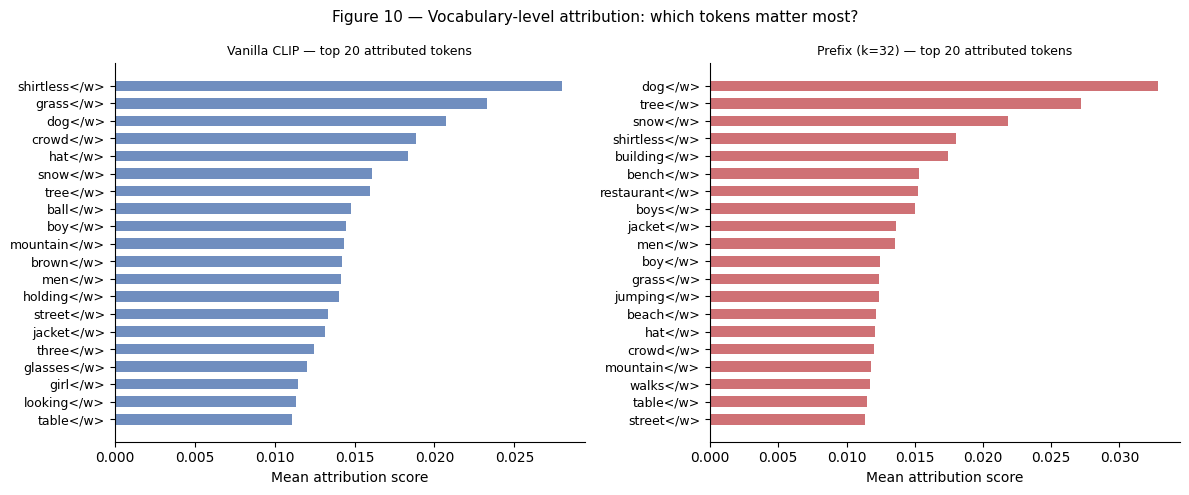

In [ ]:
#  Figure: top attributed tokens side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, top, color, title in [
    (axes[0], top_vanilla, '#4C72B0', 'Vanilla CLIP — top 20 attributed tokens'),
    (axes[1], top_prefix,  '#C44E52', 'Prefix (k=32) — top 20 attributed tokens'),
]:
    tokens = [t for t, _ in top]
    scores = [s for _, s in top]
    ys     = np.arange(len(tokens))
    ax.barh(ys[::-1], scores, color=color, alpha=0.8, height=0.6)
    ax.set_yticks(ys[::-1])
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Mean attribution score')
    ax.set_title(title, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Figure 10 — Vocabulary-level attribution: which tokens matter most?',
             fontsize=11)
plt.tight_layout()
plt.show()

## 5.5 Discussion

**Does the prefix redistribute token attribution?**

The entropy analysis over 500 test images yields a counterintuitive result: the k=32 prefix produces *lower* attribution entropy than vanilla CLIP, not higher. Mean entropy drops from 2.0697 (vanilla) to 1.7032 (prefix), a decrease of 0.3665 nats. A paired Wilcoxon signed-rank test shows that this difference is highly significant (p < 0.0001), and the effect size is medium (Cohen's d = −0.7140). The mean max-token fraction, defined as the share of total positive attribution captured by the single highest-scoring token, increases from 0.2848 under vanilla CLIP to 0.4056 under the prefix.

This means the prefix makes CLIP *more* attribution-concentrated, not less. Rather than spreading sensitivity more evenly across the sentence, the prefix sharpens the model's reliance on fewer, higher-signal tokens per caption.

This result is surprising relative to the hypothesis stated in Section 1, but it is broadly consistent with the retrieval pattern observed in Section 4. The prefix underperforms the ensemble on I→T retrieval at all k values, but slightly outperforms it on T→I R@5 and R@10. One plausible interpretation is that the prefix produces sharper, more selective text embeddings: this can help bring the correct image into the top few retrieved results when the strongest keyword signal is informative, but it may hurt when success depends on balancing multiple parts of the caption more evenly.

**What tokens matter most?**

The vocabulary-level analysis in Figure 10, aggregated over 200 examples, shows that both conditions are dominated by content-bearing tokens rather than function words. Under vanilla CLIP, the highest-attributed tokens include *shirtless* (0.0280), *grass* (0.0233), and *dog* (0.0207). Under the prefix, the top tokens shift to *dog* (0.0328), *tree* (0.0272), and *snow* (0.0219).

Several changes in the rankings are noteworthy. *Shirtless* drops from rank 1 under vanilla CLIP to rank 4 under the prefix, while nouns such as *dog*, *tree*, *snow*, and *building* become more prominent. Two action verbs, *jumping* and *walks*, also appear in the prefix top 20 but not in vanilla CLIP's. These changes suggest that the prefix does not completely alter the qualitative character of attribution, but it does shift which content tokens are emphasised and how strongly they dominate.

Overall, the fundamental structure remains similar in both conditions: CLIP, with or without the prefix, responds primarily to content-bearing scene descriptors, especially concrete nouns. The prefix does not make the model broadly compositional in the sense originally hypothesised. Instead, it appears to increase the concentration of attribution onto a smaller set of important tokens.

**Connection to Section 4 results**

The lower entropy under the prefix provides a plausible mechanism for the asymmetric retrieval results in Section 4. More concentrated text embeddings may help when retrieval is driven by a few highly informative content tokens, which fits the prefix's advantage on T→I R@5 and R@10. At the same time, this concentration may make the model less robust when successful retrieval depends on integrating the caption more holistically, which is consistent with its weaker I→T performance relative to the handcrafted ensemble.

**Limitation**

Leave-one-out attribution operates at the subword (BPE) token level, not the word level. Words such as *bicycle* and *restaurant* may be split across multiple subword tokens, distributing attribution across them. This does not invalidate the entropy or ranking statistics, but it means the per-token bars in Figure 8 and the token lists in Figure 10 should be interpreted as subword-level rather than word-level importance scores.


## 5.6 Summary

Leave-one-out attribution was computed for 500 test images under vanilla CLIP and the k=32 prefix.

| Metric | Value |
|---|---|
| Mean attribution entropy (Vanilla) | 2.0697 |
| Mean attribution entropy (Prefix) | 1.7032 |
| Delta mean entropy | −0.3665 |
| Median attribution entropy (Vanilla) | 2.0891 |
| Median attribution entropy (Prefix) | 1.6706 |
| Delta median entropy | −0.4185 |
| Mean max-token fraction (Vanilla) | 0.2848 |
| Mean max-token fraction (Prefix) | 0.4056 |
| Delta max-token fraction | +0.1209 |
| Wilcoxon p-value | < 0.0001 |
| Cohen's d | −0.7140 (medium) |


The key finding is the **opposite of the initial hypothesis**: the prefix reduces attribution entropy rather than increasing it, making CLIP more attribution-concentrated, not less. In both conditions, attribution is dominated by content-bearing scene descriptors rather than being spread evenly across the full sentence. The prefix shifts the ranking toward tokens such as *dog*, *tree*, and *snow*, while reducing the dominance of rarer highly specific tokens such as *shirtless*, but it does not fundamentally change the overall qualitative structure of attribution.

Combined with the Section 4 retrieval results, this suggests that the prefix may be working through a sharpening of text embeddings rather than through compositional broadening across the whole caption. This interpretation connects directly to the structure of CLIP's InfoNCE objective and will be revisited in the broader discussion in Section 7.

**Section 6** tests whether the prefix generalises to MS-COCO without retraining.


# Section 6: Cross-Dataset Transfer

This section answers **RQ3**: does the k=32 prefix, trained on Flickr30k, generalise to an unseen dataset without any retraining?

I evaluate on **MS-COCO** (Lin et al., 2014), a large-scale image-caption dataset with a different caption style and vocabulary from Flickr30k. The prefix has never seen any MS-COCO image or caption during training.

**Why this matters:** CoOp (Zhou et al., 2022) showed that learned prompts for classification tend to overfit to their training distribution and perform worse on unseen datasets, a limitation specifically addressed by CoCoOp. This section tests whether the same failure mode appears in the retrieval setting. If the prefix transfers well, it has learned something more general about CLIP's text embedding space. If it does not, the performance drop is consistent with CoOp's known generalisation limitation.

**Evaluation protocol:** I use the same simplified retrieval setup as in Sections 2 and 4: Recall@1/5/10 in both I→T and T→I directions, using one caption per image (the first caption in each 5-caption set). For MS-COCO, evaluation is performed on a random sample of 500 images from the validation split. Because Flickr30k is evaluated on 1,000 test images while COCO is evaluated on 500 validation images, cross-dataset absolute numbers are not directly comparable; the transfer comparison should therefore be interpreted mainly through relative performance changes across conditions.


## 6.1 Load MS-COCO

I used `phiyodr/coco2017` from HuggingFace. This dataset stores image URLs rather than raw image files, so the `COCOEvalDataset` class downloads each image on demand from the `coco_url` field.

I evaluated on **500 randomly sampled images** from the validation split. This keeps evaluation time manageable, since downloading images on the fly is relatively slow, while still providing a useful basis for transfer comparison.

In [ ]:
import torch
import numpy as np
import json
import os
import requests
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from io import BytesIO
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [ ]:
print("Loading MS-COCO metadata (images are downloaded on demand)...")
coco_raw  = load_dataset("phiyodr/coco2017", trust_remote_code=True)
coco_test = coco_raw['validation']
print(f"COCO validation split: {len(coco_test):,} images")

sample = coco_test[0]
print("\nKeys:", list(sample.keys()))
print(f"Captions per image: {len(sample['captions'])}")
print("Sample captions:")
for c in sample['captions'][:3]:
    cap = c['raw'] if isinstance(c, dict) else str(c)
    print(f"  - {cap}")

Loading MS-COCO metadata (images are downloaded on demand)...


Generating train split:   0%|          | 0/118287 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

COCO validation split: 5,000 images

Keys: ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'image_id', 'ids', 'captions']
Captions per image: 5
Sample captions:
  - A man is in a kitchen making pizzas.
  - Man in apron standing on front of oven with pans and bakeware
  - A baker is working in the kitchen rolling dough.


In [ ]:
class COCOEvalDataset(Dataset):

    def __init__(self, hf_dataset, preprocess, indices=None):
        self.data       = hf_dataset
        self.preprocess = preprocess
        self.indices    = indices if indices is not None \
                          else list(range(len(hf_dataset)))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.data[self.indices[idx]]

        url = item['coco_url']
        for attempt in range(3):           # retry up to 3 times
            try:
                resp = requests.get(url, timeout=15)
                img  = PILImage.open(BytesIO(resp.content)).convert('RGB')
                break
            except Exception:
                if attempt == 2:
                    # Return a blank image if all retries fail
                    global _coco_blank_count
                    _coco_blank_count += 1
                    img = PILImage.new('RGB', (224, 224), (128, 128, 128))
        image = self.preprocess(img)

        # Extract captions
        captions = [
            c['raw'] if isinstance(c, dict) and 'raw' in c
            else c.get('caption', str(c)) if isinstance(c, dict)
            else str(c)
            for c in item['captions']
        ]
        return image, captions


_coco_blank_count = 0

# Sample 500 images (note: Flickr30k test set uses 1,000 images - pool sizes differ)
np.random.seed(42)
N_COCO_EVAL  = 500
coco_indices = np.random.choice(len(coco_test), N_COCO_EVAL, replace=False).tolist()

coco_eval_dataset = COCOEvalDataset(coco_test, preprocess, indices=coco_indices)

def coco_collate_fn(batch):
    """
    Custom collate for COCO — transposes captions to match Flickr30k format.
    compute_recall_at_k expects captions_list[0] = first caption for all images.
    Output: (image_tensor_batch, [n_slots][batch_size]) — same as Flickr default collate.
    """
    images    = torch.stack([item[0] for item in batch])
    # Pad all caption lists to the same length so we can transpose
    max_caps  = max(len(item[1]) for item in batch)
    padded    = [item[1] + [item[1][0]] * (max_caps - len(item[1]))
                 for item in batch]
    # Transpose: [batch_size][n_caps] → [n_caps][batch_size]
    captions  = [list(slot) for slot in zip(*padded)]
    return images, captions

coco_loader = DataLoader(
    coco_eval_dataset, batch_size=16,
    shuffle=False, num_workers=4,
    collate_fn=coco_collate_fn
)

print(f"COCO eval dataset : {len(coco_eval_dataset)} images")
print(f"COCO eval batches : {len(coco_loader)}")
print("Note: each batch downloads images from COCO servers — expect ~2s per batch.")

COCO eval dataset : 500 images
COCO eval batches : 32
Note: each batch downloads images from COCO servers — expect ~2s per batch.


In [ ]:
print("Downloading one test image to verify the pipeline...")
imgs, caps = next(iter(DataLoader(coco_eval_dataset, batch_size=1, shuffle=False)))
print(f"Image shape : {imgs.shape}")
print(f"Captions    : {[c[0] for c in caps]}")
print("\nSanity check passed — pipeline is working.")

Image shape : torch.Size([1, 3, 224, 224])
Captions    : ['A computer desk topped with two monitors and a laptop.', 'a table with so many screen and a keyboard', 'A desk has two computer monitors, a keyboard, and a laptop that is all connected.', 'A computer desk with two monitors and a laptop.', 'A desk with a laptop, two monitors, two speakers, a keyboard, a mouse and a cell phone on it. ']

Sanity check passed — pipeline is working.


## 6.2 Evaluate all conditions on MS-COCO


In [ ]:
print("[1/3] Vanilla CLIP on COCO...")
coco_vanilla = compute_recall_at_k(
    model, coco_loader, tokenizer, DEVICE,
    prefix=None, k_vals=(1, 5, 10),
    desc="COCO vanilla"
)
save_results(coco_vanilla, "coco_vanilla")
print_results(coco_vanilla, label="COCO — Vanilla CLIP")
if _coco_blank_count > 0:
    print(f"Warning: {_coco_blank_count} COCO images failed to download and were replaced with blank images.")

[1/3] Vanilla CLIP on COCO...


COCO vanilla:   0%|          | 0/32 [00:00<?, ?it/s]

Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/coco_vanilla.json

──────────────────────────────────────────
  COCO — Vanilla CLIP  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          58.40%
  t2i_R@1          50.80%
  i2t_R@5          88.60%
  t2i_R@5          81.40%
  i2t_R@10         94.20%
  t2i_R@10         93.40%
──────────────────────────────────────────


In [ ]:
print("[2/3] Ensemble on COCO...")
coco_ensemble = compute_recall_ensemble(
    model, coco_loader, tokenizer, DEVICE,
    templates=ENSEMBLE_TEMPLATES,
    k_vals=(1, 5, 10), desc="COCO ensemble"
)
save_results(coco_ensemble, "coco_ensemble")
print_results(coco_ensemble, label="COCO — Ensemble (5 templates)")

[2/3] Ensemble on COCO...


COCO ensemble:   0%|          | 0/32 [00:00<?, ?it/s]

Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/coco_ensemble.json

──────────────────────────────────────────
  COCO — Ensemble (5 templates)  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          58.60%
  i2t_R@5          88.60%
  i2t_R@10         94.80%
  t2i_R@1          53.00%
  t2i_R@5          83.00%
  t2i_R@10         92.80%
──────────────────────────────────────────


In [ ]:
print("[3/3] Prefix k=32 on COCO (zero-shot transfer)...")
coco_prefix = compute_recall_at_k(
    model, coco_loader, tokenizer, DEVICE,
    prefix=best_prefix, k_vals=(1, 5, 10),
    desc="COCO prefix k=32"
)
save_results(coco_prefix, "coco_prefix_k32")
print_results(coco_prefix, label="COCO — Prefix k=32 (zero-shot)")

[3/3] Prefix k=32 on COCO (zero-shot transfer)...


COCO prefix k=32:   0%|          | 0/32 [00:00<?, ?it/s]

Results saved → /content/drive/MyDrive/IPCVDL2_Project/results/coco_prefix_k32.json

──────────────────────────────────────────
  COCO — Prefix k=32 (zero-shot)  
──────────────────────────────────────────
  Metric            Score
  ────────────────────────
  i2t_R@1          53.60%
  t2i_R@1          50.60%
  i2t_R@5          85.60%
  t2i_R@5          82.60%
  i2t_R@10         95.40%
  t2i_R@10         92.80%
──────────────────────────────────────────


## 6.3 Transfer comparison table

Flickr30k and MS-COCO results are shown side by side. The transfer-gap column shows how much each condition changes when moving from Flickr30k to the unseen dataset.


In [ ]:
# Load Flickr30k results
flickr_vanilla  = load_results("baseline_vanilla")
flickr_ensemble = load_results("baseline_ensemble")
flickr_prefix   = load_results("prefix_k32_test")

metrics = ["i2t_R@1", "i2t_R@5", "i2t_R@10", "t2i_R@1", "t2i_R@5", "t2i_R@10"]

# Full transfer table
for condition, flickr, coco in [
    ("Vanilla CLIP",  flickr_vanilla,  coco_vanilla),
    ("Ensemble (5)",  flickr_ensemble, coco_ensemble),
    ("Prefix (k=32)", flickr_prefix,   coco_prefix),
]:
    print(f"\n{condition}")
    print(f"  {'Metric':<14} {'Flickr30k':>10} {'COCO':>10} {'Gap':>10}")
    print(f"  {'─'*46}")
    for m in metrics:
        gap  = coco[m] - flickr[m]
        sign = "+" if gap >= 0 else ""
        print(f"  {m:<14} {flickr[m]:>9.2f}% {coco[m]:>9.2f}% {sign}{gap:>7.2f}pp")

# I→T R@1 summary
print("\n" + "=" * 54)
print("I→T R@1 transfer gap summary")
print(f"  {'Condition':<20} {'Flickr':>8} {'COCO':>8} {'Gap':>8}")
print("  " + "─" * 46)
for name, flickr, coco in [
    ("Vanilla CLIP",  flickr_vanilla,  coco_vanilla),
    ("Ensemble (5)",  flickr_ensemble, coco_ensemble),
    ("Prefix (k=32)", flickr_prefix,   coco_prefix),
]:
    gap  = coco["i2t_R@1"] - flickr["i2t_R@1"]
    sign = "+" if gap >= 0 else ""
    print(f"  {name:<20} {flickr['i2t_R@1']:>7.2f}% "
          f"{coco['i2t_R@1']:>7.2f}% {sign}{gap:>5.2f}pp")


Vanilla CLIP
  Metric          Flickr30k       COCO        Gap
  ──────────────────────────────────────────────
  i2t_R@1            69.60%     58.40%  -11.20pp
  i2t_R@5            90.50%     88.60%   -1.90pp
  i2t_R@10           95.00%     94.20%   -0.80pp
  t2i_R@1            67.20%     50.80%  -16.40pp
  t2i_R@5            89.00%     81.40%   -7.60pp
  t2i_R@10           93.80%     93.40%   -0.40pp

Ensemble (5)
  Metric          Flickr30k       COCO        Gap
  ──────────────────────────────────────────────
  i2t_R@1            72.20%     58.60%  -13.60pp
  i2t_R@5            92.30%     88.60%   -3.70pp
  i2t_R@10           95.50%     94.80%   -0.70pp
  t2i_R@1            68.20%     53.00%  -15.20pp
  t2i_R@5            89.00%     83.00%   -6.00pp
  t2i_R@10           94.00%     92.80%   -1.20pp

Prefix (k=32)
  Metric          Flickr30k       COCO        Gap
  ──────────────────────────────────────────────
  i2t_R@1            69.30%     53.60%  -15.70pp
  i2t_R@5            90

## 6.4 Visualisation

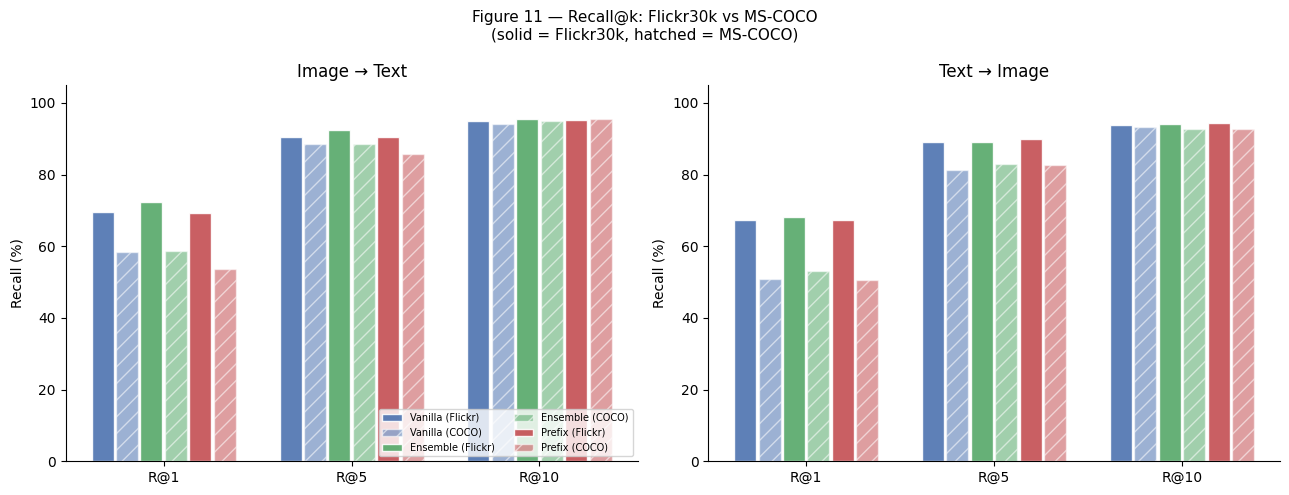

In [ ]:
# Figure: grouped bar chart Flickr vs COCO
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conditions = [
    ("Vanilla (Flickr)",  flickr_vanilla,  "#4C72B0", None),
    ("Vanilla (COCO)",    coco_vanilla,    "#4C72B0", "//"),
    ("Ensemble (Flickr)", flickr_ensemble, "#55A868", None),
    ("Ensemble (COCO)",   coco_ensemble,   "#55A868", "//"),
    ("Prefix (Flickr)",   flickr_prefix,   "#C44E52", None),
    ("Prefix (COCO)",     coco_prefix,     "#C44E52", "//"),
]
x     = np.arange(3)
width = 0.13
k_labels = ["R@1", "R@5", "R@10"]

for ax, metric_keys, title in [
    (axes[0], ["i2t_R@1", "i2t_R@5", "i2t_R@10"], "Image → Text"),
    (axes[1], ["t2i_R@1", "t2i_R@5", "t2i_R@10"], "Text → Image"),
]:
    for i, (label, results, color, hatch) in enumerate(conditions):
        vals   = [results[m] for m in metric_keys]
        offset = (i - len(conditions) / 2 + 0.5) * width
        alpha  = 0.9 if hatch is None else 0.55
        ax.bar(x + offset, vals, width * 0.9, label=label,
               color=color, alpha=alpha, hatch=hatch, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(k_labels)
    ax.set_ylabel("Recall (%)")
    ax.set_title(title)
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(fontsize=7, ncol=2, loc="lower right")
fig.suptitle(
    "Figure 11 — Recall@k: Flickr30k vs MS-COCO\n"
    "(solid = Flickr30k, hatched = MS-COCO)",
    fontsize=11
)
plt.tight_layout()
plt.show()

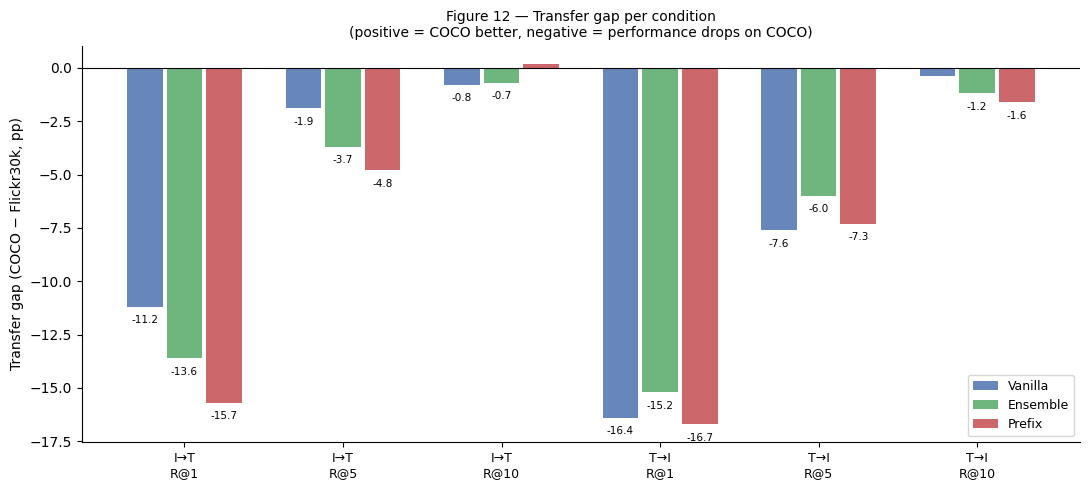

In [ ]:
# Figure: transfer gap per metric
metrics_short = ["I→T\nR@1", "I→T\nR@5", "I→T\nR@10",
                 "T→I\nR@1", "T→I\nR@5", "T→I\nR@10"]
x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, flickr, coco, color) in enumerate([
    ("Vanilla",  flickr_vanilla,  coco_vanilla,  "#4C72B0"),
    ("Ensemble", flickr_ensemble, coco_ensemble, "#55A868"),
    ("Prefix",   flickr_prefix,   coco_prefix,   "#C44E52"),
]):
    gaps   = [coco[m] - flickr[m] for m in metrics]
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, gaps, width * 0.9,
                    label=name, color=color, alpha=0.85)
    for bar, g in zip(bars, gaps):
        if abs(g) > 0.5:
            va   = "bottom" if g >= 0 else "top"
            ypos = g + 0.4 if g >= 0 else g - 0.4
            ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                    f"{g:+.1f}", ha="center", va=va, fontsize=7.5)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics_short, fontsize=9)
ax.set_ylabel("Transfer gap (COCO − Flickr30k, pp)")
ax.set_title(
    "Figure 12 — Transfer gap per condition\n"
    "(positive = COCO better, negative = performance drops on COCO)",
    fontsize=10
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6.5 Discussion

The k=32 prefix shows the largest I→T R@1 transfer gap of the three conditions: performance drops from 69.30% on Flickr30k to 53.60% on COCO, a decrease of 15.70 percentage points. This drop is larger than the corresponding decreases for vanilla CLIP (−11.20pp) and the ensemble (−13.60pp). Within the evaluation protocol used in this notebook, this is consistent with the prefix being the least robust of the three conditions under dataset shift.

A plausible explanation is that the learned prefix has adapted to the stylistic regularities of Flickr30k captions. Flickr30k captions are often longer and more descriptive, whereas COCO captions tend to be shorter and more literal. If the prefix encodes a text-side adjustment that is well matched to Flickr30k's caption distribution, that same adjustment may become less appropriate when applied unchanged to COCO.

The pattern is broadly consistent across metrics. The prefix has the largest gap on T→I R@1 as well (−16.70pp), and its I→T R@5 and T→I R@10 gaps are also worse than those of the ensemble. One exception is I→T R@10, where the prefix shows a very small positive change (+0.20pp), suggesting that at a loose retrieval threshold the distribution shift matters much less. Overall, however, the transfer pattern supports the conclusion that the learned prefix is less robust out of distribution than either vanilla CLIP or the handcrafted ensemble.

The ensemble's smaller transfer gap is plausibly related to its more domain-agnostic construction. Because it averages several generic prompt phrasings rather than learning a fixed dataset-specific embedding shift, it may be less sensitive to the stylistic details of the training captions. The prefix, despite using far fewer parameters than a fully fine-tuned model, still appears to encode enough distribution-specific information to lose robustness when moved to a new dataset.

This finding connects naturally to the CoCoOp motivation. A fixed learned prefix applies the same text-side adjustment to every caption regardless of content or domain. CoCoOp was designed to address this kind of brittleness by conditioning the prompt on the input instance. While my setup is retrieval rather than classification, the qualitative pattern is similar: a fixed learned prompt helps in distribution, but transfers less well than hoped.

One mitigating observation is that the prefix is still far above chance performance on COCO. The transfer drop is substantial, but not catastrophic. So the result is best interpreted as partial overfitting to Flickr30k's caption distribution rather than complete failure outside the training domain.

Because Flickr30k and COCO are evaluated with different retrieval pool sizes in this notebook (1,000 vs 500 images), these cross-dataset differences should be interpreted cautiously. The most reliable conclusion is the relative ordering across conditions: under the same transfer setup, the prefix degrades more than vanilla CLIP and more than the handcrafted ensemble.

## 6.6 Summary

The k=32 prefix was evaluated on 500 MS-COCO validation images without retraining (zero-shot transfer from Flickr30k).

| Condition | Flickr I→T R@1 | COCO I→T R@1 | Transfer gap |
|---|---|---|---|
| Vanilla CLIP | 69.60% | 58.40% | −11.20pp |
| Ensemble (5) | 72.20% | 58.60% | −13.60pp |
| Prefix (k=32) | 69.30% | 53.60% | −15.70pp |

Under the transfer setup used in this notebook, the prefix shows the largest I→T R@1 transfer gap of the three conditions. This is consistent with the learned prefix being less robust to dataset shift than either vanilla CLIP or the handcrafted ensemble. A plausible interpretation is that the prefix has encoded aspects of Flickr30k's caption distribution that do not transfer as well to MS-COCO's shorter, more factual captions.

Because Flickr30k and COCO are evaluated with different retrieval pool sizes in this notebook, the absolute cross-dataset numbers should be interpreted cautiously. The strongest conclusion is the relative ordering across conditions: under the same transfer protocol, the prefix degrades more than the baselines.



# Section 7: Discussion & Limitations

This section synthesises the findings from Sections 1–6 into a unified account of what the soft prefix does and does not do in CLIP's embedding space, situates the results within the broader literature on prompt learning for vision-language models, and identifies the limitations that bound the conclusions of this project.



## 7.1 What the experiments show collectively

**The three research questions, answered:**

**RQ1 — Does a learned soft prefix improve Recall@k over a handcrafted template ensemble?**  
No. Under the simplified 1-caption-per-image Flickr30k evaluation used in this notebook, the k=32 prefix achieves 69.30% I→T R@1 on the test set, falling 2.90pp short of the 5-template ensemble (72.20%). The prefix also remains slightly below the ensemble at T→I R@1, but it does outperform it at T→I R@5 (+0.90pp) and T→I R@10 (+0.40pp). The overall pattern is therefore asymmetric: the handcrafted ensemble is stronger at the strictest retrieval threshold, while the learned prefix becomes competitive, and occasionally better, once the metric allows a broader ranking window.


**RQ2 — Does the prefix change which tokens drive cosine similarity?**  
Yes, but in the opposite direction from the initial hypothesis. Mean attribution entropy drops from 2.0697 (vanilla) to 1.7032 (prefix), a statistically significant decrease (Wilcoxon p < 0.0001, Cohen's d = −0.7140). The prefix makes CLIP *more* attribution-concentrated, not less. The mean fraction of positive attribution captured by the single highest-scoring token increases from 0.2848 to 0.4056 under the prefix. In both conditions, the highest-attributed tokens are dominated by content-bearing scene descriptors rather than being spread evenly across the full sentence. The prefix therefore sharpens token concentration rather than distributing sensitivity more broadly.


**RQ3 — Does the prefix generalise to an unseen dataset?**  
Not especially well. Under the transfer setup used in this notebook, the prefix shows the largest I→T R@1 transfer gap of the three conditions: performance drops by 15.70pp from Flickr30k to MS-COCO, compared with drops of 11.20pp for vanilla CLIP and 13.60pp for the ensemble. This is consistent with the learned prefix being less robust to dataset shift than the baselines, and plausibly reflects adaptation to the stylistic regularities of Flickr30k captions, which do not transfer as well to COCO's shorter, more factual descriptions. Because the two datasets are evaluated with different retrieval pool sizes in this notebook, this conclusion should be interpreted mainly through the relative ordering across conditions rather than through direct comparison of the absolute scores.


## 7.2 A coherent interpretation across findings

The three findings form a broadly consistent picture when interpreted together.

The prefix appears to learn a fixed text-side adjustment in CLIP's embedding space that improves some aspects of in-distribution retrieval without surpassing the best handcrafted ensemble on the main benchmark. Because it is trained with InfoNCE on Flickr30k batches of 64, it is optimised under a relatively local contrastive objective and on a specific caption distribution. The attribution results suggest that this learned adjustment concentrates similarity more strongly onto a smaller set of high-signal content tokens, especially scene-describing nouns such as *dog*, *snow*, and *tree*. This is consistent with the Section 4 result that the prefix becomes competitive, and sometimes better, at broader T→I retrieval thresholds, while still falling short of the ensemble at I→T R@1.

When evaluated out of distribution on MS-COCO, the same fixed learned adjustment transfers less well than either vanilla CLIP or the handcrafted ensemble. A plausible interpretation is that the prefix has adapted to statistical regularities in Flickr30k captioning style and therefore becomes less appropriate when applied unchanged to COCO's shorter, more factual captions. The ensemble, by contrast, relies on generic prompt averaging rather than a learned dataset-specific shift, which may make it less sensitive to this kind of distribution mismatch.

The prefix-length ablation supports this interpretation. Validation I→T R@1 increases strongly with capacity (k=4: 22.98%, k=8: 29.39%, k=16: 42.70%, k=32: 65.78% after 5 epochs), showing that larger prefixes can encode a much stronger retrieval-relevant adjustment. At the same time, the transfer analysis suggests that this extra capacity may also make the learned prompt more sensitive to the training distribution. In that sense, the same property that improves in-distribution performance may also contribute to reduced robustness under dataset shift.


## 7.3 Comparison with CoOp and CoCoOp

These results are broadly consistent with CoOp's central in-distribution idea: a learned soft prompt can provide meaningful gains over a raw baseline while keeping the underlying vision-language model frozen. In my retrieval setting, the k=32 prefix improves substantially over vanilla CLIP and narrows the gap to the handcrafted ensemble, even though it does not surpass that ensemble on the headline I→T R@1 metric.

At the same time, the results differ from CoOp's classification findings in an important way. In CoOp, learned prompts often outperform handcrafted templates on the in-distribution task, whereas here the learned prefix remains below the ensemble on the main Flickr30k benchmark. One plausible reason is that retrieval is a harder and less structured objective than classification: instead of choosing among a fixed label set, the model must rank a large retrieval pool using free-form text. That makes the in-batch contrastive training signal a looser proxy for the final evaluation setting. Another possibility is that the 5-template ensemble used here is already a particularly strong handcrafted baseline for this dataset.

The transfer results are also qualitatively consistent with the motivation behind CoCoOp. In this notebook, a fixed learned prefix transfers less well than the baselines under dataset shift, suggesting that a single frozen prompt adjustment may be too inflexible outside the training distribution. CoCoOp addresses an analogous issue in classification by conditioning the prompt on the input instance. In the retrieval setting studied here, an image-conditioned or instance-adaptive prefix would be a natural next step for testing whether this kind of conditioning improves robustness across datasets.

## 7.4 Limitations

**In-batch training signal.** The InfoNCE loss is computed on batches of 64 image-caption pairs. The prefix is therefore optimised to discriminate among in-batch negatives, but evaluated against a much larger retrieval pool at test time. This train-evaluation mismatch is a clear limitation of the setup and likely contributes to the gap between what the prefix learns during training and what is required for strong full-pool retrieval.

**Simplified retrieval protocol.** All retrieval results in this notebook use a simplified 1-caption-per-image protocol rather than the standard 5-caption Flickr30k benchmark. This does not invalidate the within-project comparisons, since the same protocol is used consistently across all conditions, but it does mean the absolute Recall@k numbers are not directly comparable to published benchmark results.

**Cross-dataset pool-size mismatch.** Flickr30k is evaluated on 1,000 test images, while MS-COCO transfer is evaluated on a random sample of 500 validation images. Because Recall@k depends on retrieval pool size, the transfer analysis should be interpreted mainly through the relative ordering across conditions rather than through direct comparison of absolute cross-dataset gaps.

**Single dataset and domain.** All training is on Flickr30k, a photographic dataset with a particular captioning style. The transfer results to COCO are informative, but both datasets remain within the broad natural-image domain. A stronger test of generality would involve transfer to more domain-shifted settings such as medical imaging, remote sensing, or artwork.

**Leave-one-out attribution at the subword level.** The attribution analysis operates at the BPE token level, not the word level. Rare or compound words may be split across multiple subword tokens, distributing their attribution signal. This does not invalidate the entropy or ranking results, but it means the attribution bars and token-level statistics should be interpreted as subword-level rather than word-level measures.

**No carbon tracking.** The project proposal included carbon cost measurement using CodeCarbon as an optional extension, but this was not implemented. Given that the ablation required additional training runs and that the evaluation pipeline was executed multiple times across Flickr30k and COCO, a carbon analysis would have added a useful socio-environmental dimension to the project.

**Prefix initialisation sensitivity.** I initialised the prefix from the token embeddings of `"a photo of a"` following CoOp. I did not test random initialisation or alternative warm-start strings. CoOp reports that initialisation mainly affects convergence speed rather than final performance, but this has not been verified here in the retrieval setting.

Similarly, attention/GradCAM-style visualisation of which image regions drive retrieval was proposed as an optional extension in the project proposal but was not implemented within the project scope.

## 7.5 What a stronger version of this project would do differently

Given unlimited time, the most valuable extensions would be:

1. **Train with larger batch sizes or hard negative mining.** The current 64-image in-batch objective is likely the main training bottleneck. Training with much larger batches, or incorporating hard negatives, would make the optimisation signal better match the retrieval setting used at evaluation time.

2. **Implement a CoCoOp-style conditional prefix.** Adding a small meta-network that adjusts the prefix based on image features would directly test whether instance-conditioned prompting improves robustness under dataset shift.

3. **Run attribution at the word level.** Merging BPE subword attributions back into word-level scores would produce cleaner entropy statistics and more interpretable vocabulary-level comparisons.

4. **Test on a more strongly domain-shifted dataset.** Applying the prefix to a genuinely out-of-distribution setting, such as medical image captions, remote sensing descriptions, or artwork, would provide a much stronger test of what Flickr30k-trained prefix vectors can and cannot transfer.


# Section 8: References

1. Radford, A., Kim, J. W., Hallacy, C., Ramesh, A., Goh, G., Agarwal, S., Sastry, G., Askell, A., Mishkin, P., Clark, J., Krueger, G., & Sutskever, I. (2021). *Learning Transferable Visual Models From Natural Language Supervision.* In *Proceedings of the 38th International Conference on Machine Learning (ICML)*, PMLR 139, 8748–8763. https://proceedings.mlr.press/v139/radford21a.html

2. Zhou, K., Yang, J., Loy, C. C., & Liu, Z. (2022). *Learning to Prompt for Vision-Language Models.* *International Journal of Computer Vision*, 130(9), 2337–2348. https://doi.org/10.1007/s11263-022-01653-1

3. Zhou, K., Yang, J., Loy, C. C., & Liu, Z. (2022). *Conditional Prompt Learning for Vision-Language Models.* In *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, 16816–16825. https://openaccess.thecvf.com/content/CVPR2022/html/Zhou_Conditional_Prompt_Learning_for_Vision-Language_Models_CVPR_2022_paper.html

4. Young, P., Lai, A., Hodosh, M., & Hockenmaier, J. (2014). *From image descriptions to visual denotations: New similarity metrics for semantic inference over event descriptions.* *Transactions of the Association for Computational Linguistics*, 2, 67–78. https://aclanthology.org/Q14-1006/

5. Lin, T.-Y., Maire, M., Belongie, S., Hays, J., Perona, P., Ramanan, D., Dollár, P., & Zitnick, C. L. (2014). *Microsoft COCO: Common Objects in Context.* In *Proceedings of the European Conference on Computer Vision (ECCV)*, 740–755. https://www.microsoft.com/en-us/research/publication/microsoft-coco-common-objects-in-context/

6. Ilharco, G., Wortsman, M., Wightman, R., Gordon, C., Carlini, N., Taori, R., Dave, A., Shankar, V., Namkoong, H., Miller, J., Hajishirzi, H., Farhadi, A., & Schmidt, L. (2024). *OpenCLIP* (Version v2.24.0) [Software]. Zenodo. https://doi.org/10.5281/zenodo.10469088

7. Loshchilov, I., & Hutter, F. (2019). Decoupled Weight Decay Regularization. In International Conference on Learning Representations (ICLR). https://openreview.net/forum?id=Bkg6RiCqY7

8. van den Oord, A., Li, Y., & Vinyals, O. (2018). *Representation Learning with Contrastive Predictive Coding.* arXiv. https://arxiv.org/abs/1807.03748

9. Shen, S., Li, L. H., Tan, H., Bansal, M., Rohrbach, A., Chang, K.-W., Yao, Z., & Keutzer, K. (2022). *How Much Can CLIP Benefit Vision-and-Language Tasks?* In *International Conference on Learning Representations (ICLR)*. https://openreview.net/forum?id=zf_Ll3HZWgy
